In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [3]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

In [4]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,7.97,27.3,104.3,44.8,94.0,Drip,271.1,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,6.57,33.7,127.8,44.9,91.3,Drip,176.6,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,7.25,21.1,126.7,59.9,148.0,Drip,234.7,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,6.11,30.5,107.5,20.7,91.0,Sprinkler,329.7,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,6.16,35.7,137.1,92.6,145.5,Sprinkler,205.9,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


In [7]:
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [9]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,186.036000,5.070935,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,60.260583,1.978879,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,40.000000,0.500000,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,143.975000,3.690000,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,186.250000,5.120000,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,227.200000,6.400000,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,400.000000,12.080000,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [10]:
df.describe(include='all') #for both numerical and categorical columns

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000,4000,4000,4000,4000,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,4000,4000.000000,4000.000000,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
unique,4000,8,10,8,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Flood,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,529,427,690,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1310,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,NaN,186.036000,5.070935,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,NaN,NaN,NaN,NaN,NaN,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,NaN,60.260583,1.978879,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,NaN,NaN,NaN,NaN,NaN,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,NaN,40.000000,0.500000,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,NaN,NaN,NaN,NaN,NaN,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,NaN,143.975000,3.690000,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,NaN,NaN,NaN,NaN,NaN,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,NaN,186.250000,5.120000,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,NaN,NaN,NaN,NaN,NaN,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,NaN,227.200000,6.400000,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000


In [11]:
missing_values = df.isnull().sum()

print(missing_values)

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [12]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': missing_percentage
})

missing_df = missing_df[missing_df['Missing Values'] > 0]

missing_df.sort_values(
    by='Percentage',
    ascending=False
)

,Missing Values,Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [13]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [14]:
for column in df.columns:
    print(f"\n--- {column} ---")
    print("Unique values:", df[column].nunique())


--- Farm_ID ---
Unique values: 4000

--- State ---
Unique values: 8

--- District ---
Unique values: 10

--- Crop ---
Unique values: 8

--- Season ---
Unique values: 3

--- Farm_Area_Hectares ---
Unique values: 1370

--- Rainfall_mm ---
Unique values: 3256

--- Avg_Temperature_C ---
Unique values: 204

--- Humidity_pct ---
Unique values: 573

--- Sunlight_Hours_Day ---
Unique values: 71

--- Soil_pH ---
Unique values: 313

--- Soil_Moisture_pct ---
Unique values: 343

--- Nitrogen_kg_ha ---
Unique values: 1229

--- Phosphorus_kg_ha ---
Unique values: 760

--- Potassium_kg_ha ---
Unique values: 1137

--- Irrigation_Method ---
Unique values: 4

--- Fertilizer_kg_ha ---
Unique values: 1881

--- Pesticide_Litre_ha ---
Unique values: 851

--- Seed_Quality_Score ---
Unique values: 36

--- Yield_Tonnes_Ha ---
Unique values: 738

--- Production_Tonnes ---
Unique values: 2528

--- Market_Price_INR_Tonne ---
Unique values: 3760

--- Total_Cost_INR ---
Unique values: 3995

--- Revenue_INR ---
Un

In [15]:
categorical_columns = df.select_dtypes(
    include=['object', 'category']
).columns

print("Categorical columns:")
print(categorical_columns.tolist())

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


In [16]:
for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts().head(20))


--- Farm_ID ---
Farm_ID
SF13984    1
SF13983    1
SF13982    1
SF13981    1
SF13980    1
SF13979    1
SF13978    1
SF13977    1
SF13976    1
SF13975    1
SF13974    1
SF13973    1
SF13972    1
SF13971    1
SF13970    1
SF13969    1
SF10032    1
SF10031    1
SF10030    1
SF10029    1
Name: count, dtype: int64

--- State ---
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

--- District ---
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

--- Crop ---
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

--- Season ---
Season
Kharif    1779
Rabi      1627
Zaid       594
Name

In [17]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns

print("Numerical columns:")
print(numerical_columns.tolist())

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [18]:
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


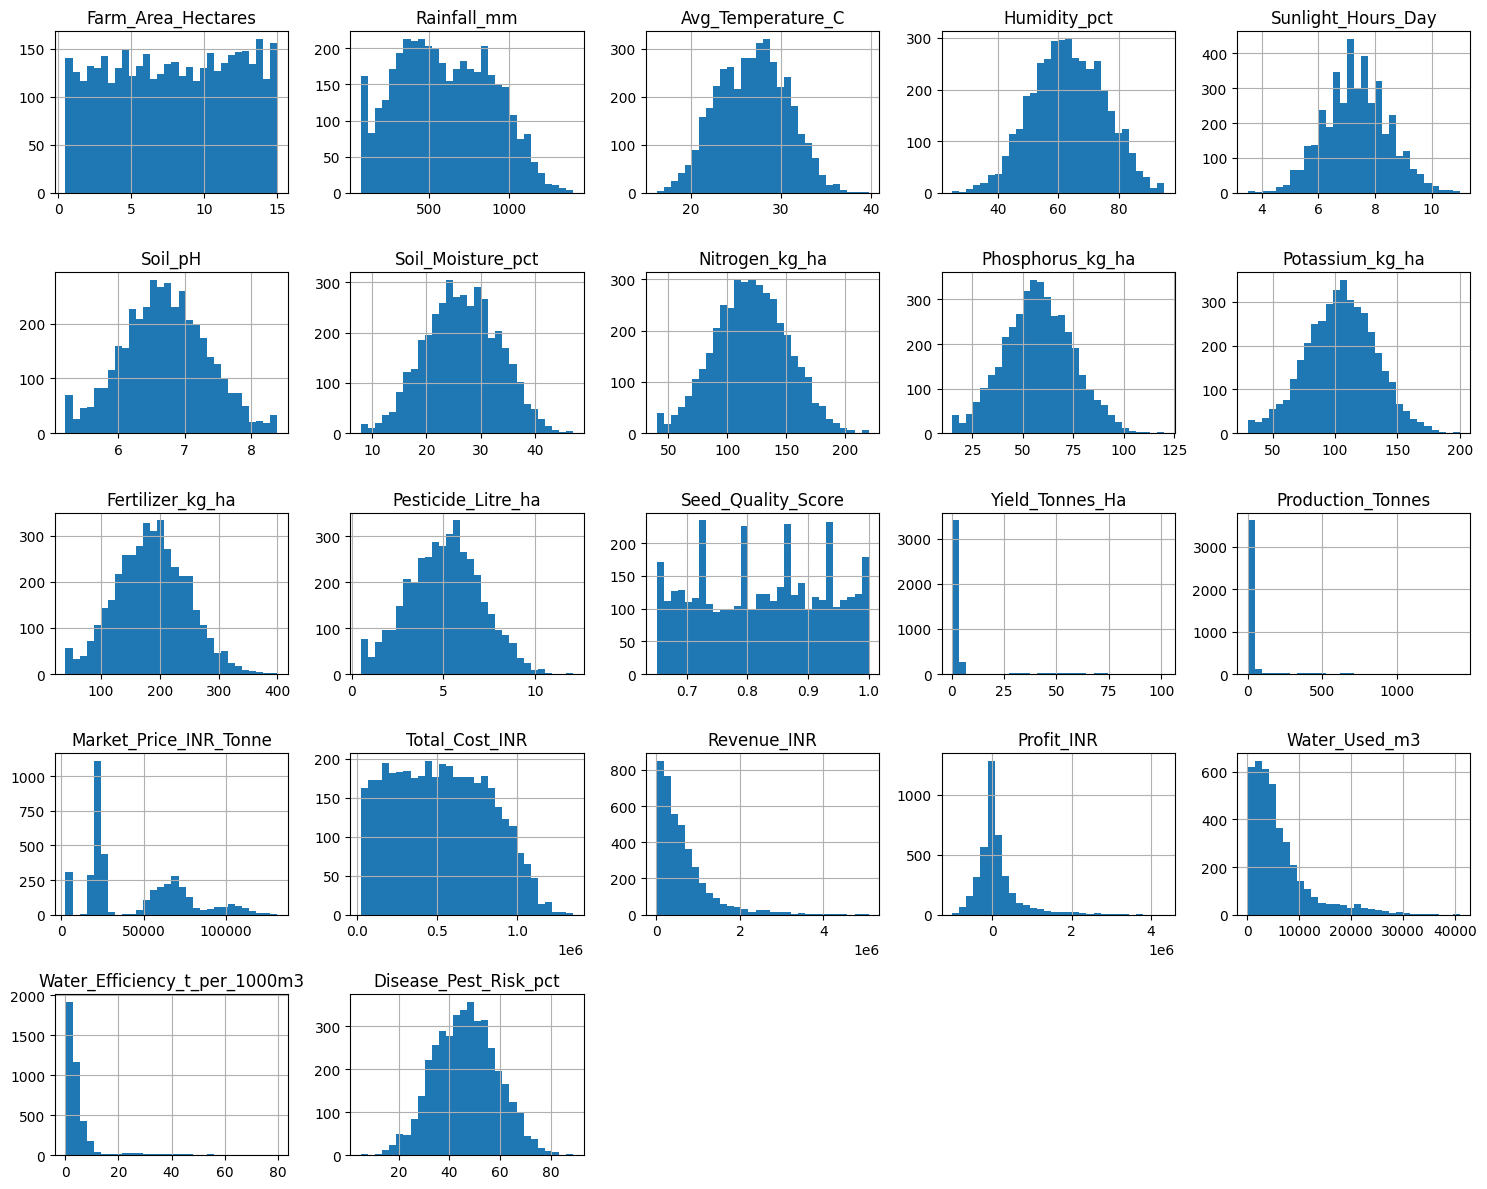

In [19]:
df[numerical_columns].hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

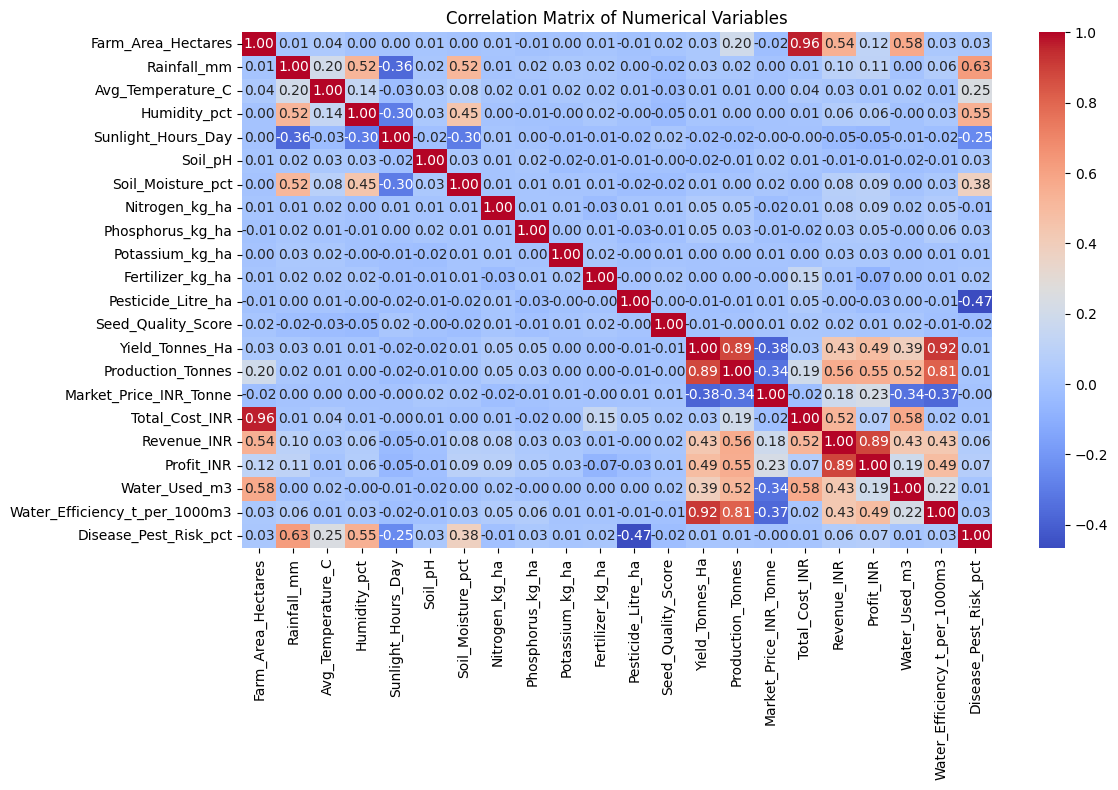

In [20]:
correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

In [22]:
missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    'Missing_Values': missing_values,
    'Missing_Percentage': (missing_values / len(df)) * 100
})

missing_df = missing_df[
    missing_df['Missing_Values'] > 0
].sort_values(
    by='Missing_Percentage',
    ascending=False
)

missing_df

,Missing_Values,Missing_Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [23]:
season_counts = df['Season'].value_counts()

print(season_counts)

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


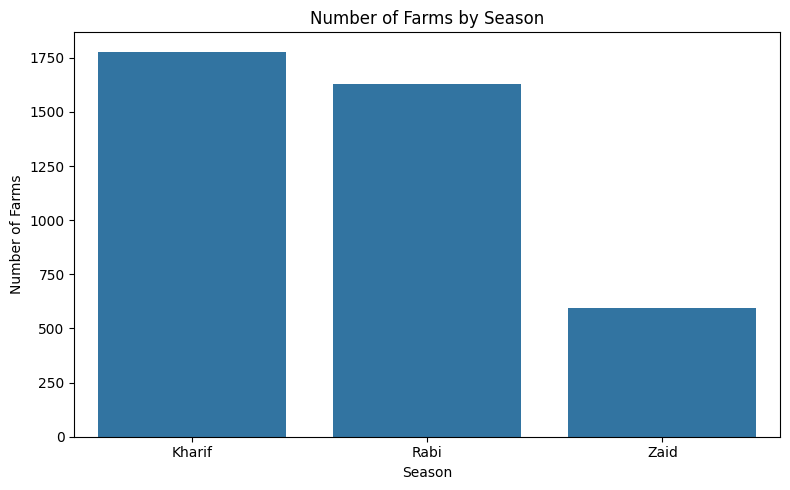

In [24]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Season',
    order=df['Season'].value_counts().index
)

plt.title('Number of Farms by Season')
plt.xlabel('Season')
plt.ylabel('Number of Farms')

plt.tight_layout()
plt.show()

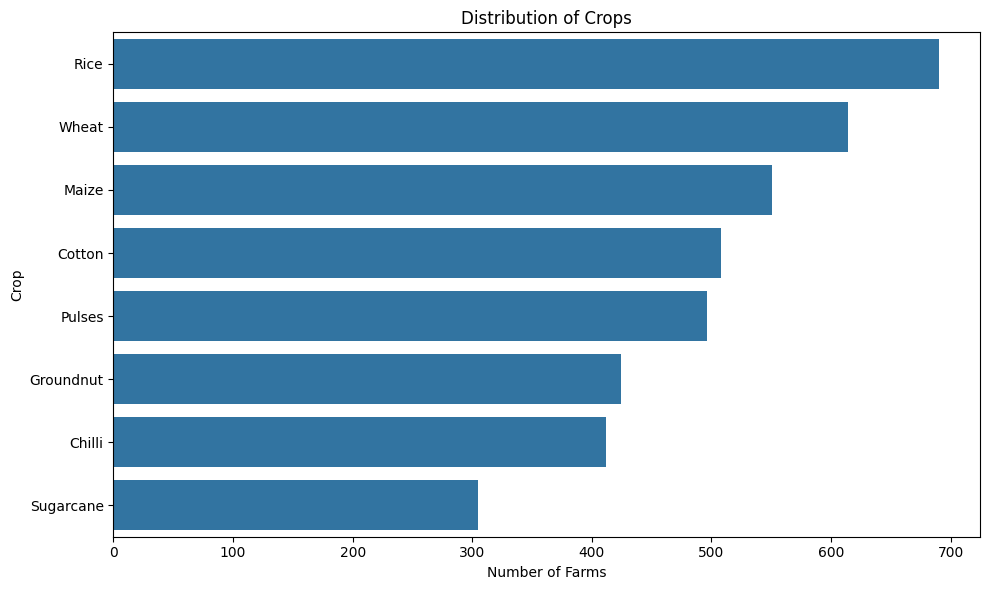

In [25]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y='Crop',
    order=df['Crop'].value_counts().index
)

plt.title('Distribution of Crops')
plt.xlabel('Number of Farms')
plt.ylabel('Crop')

plt.tight_layout()
plt.show()

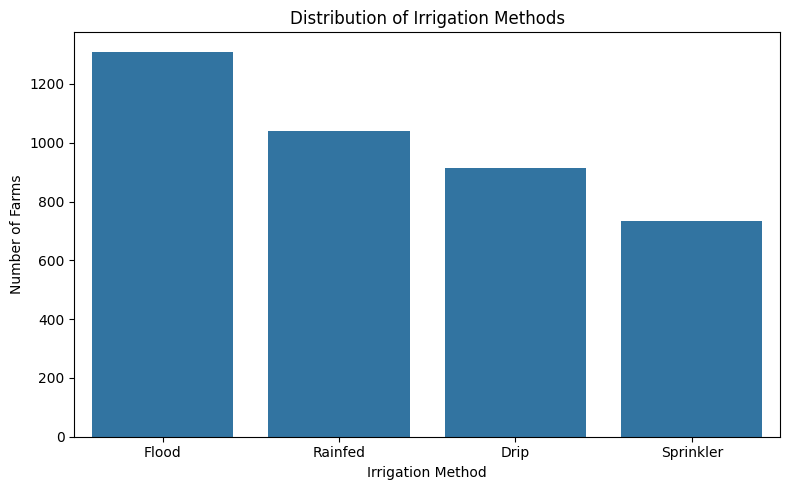

In [26]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Irrigation_Method',
    order=df['Irrigation_Method'].value_counts().index
)

plt.title('Distribution of Irrigation Methods')
plt.xlabel('Irrigation Method')
plt.ylabel('Number of Farms')

plt.tight_layout()
plt.show()

In [27]:
season_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)

season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,5.64,46.31,710719.06,531804.41,178914.65,6102.20,5.89,54.47
Rabi,5.08,41.49,601526.05,513836.58,87689.47,5846.99,5.19,40.48
Zaid,4.67,38.89,519171.90,543976.73,-24804.82,6419.89,4.41,38.22


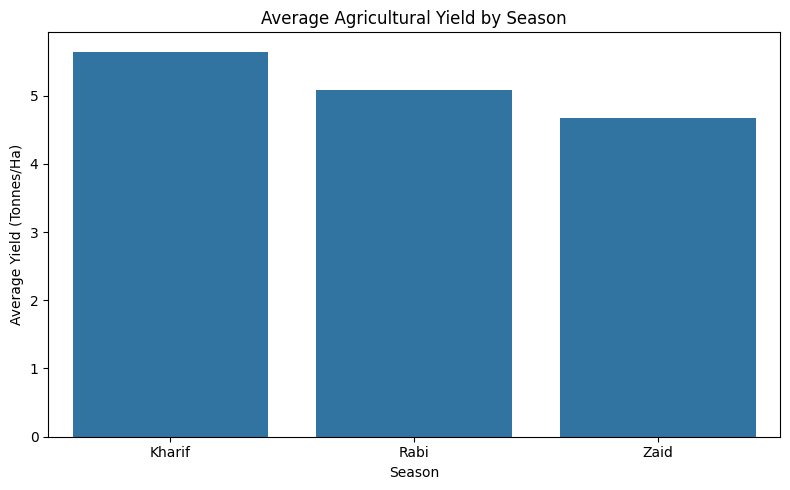

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha',
    estimator='mean',
    errorbar=None
)

plt.title('Average Agricultural Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

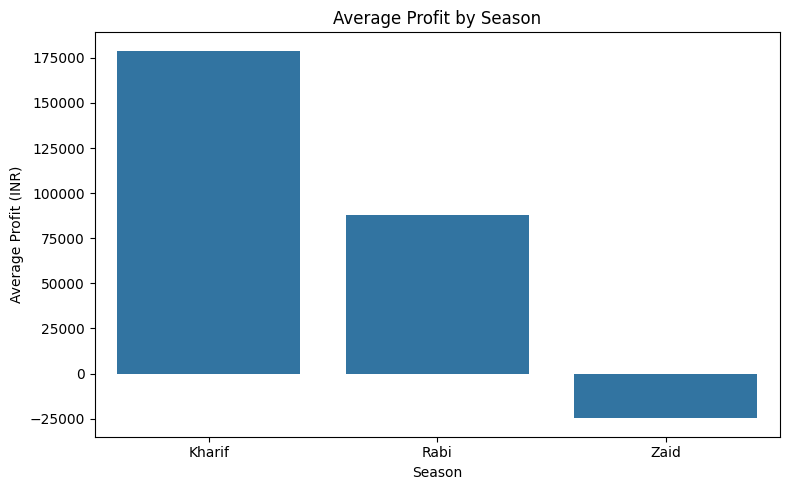

In [29]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Profit_INR',
    estimator='mean',
    errorbar=None
)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

plt.tight_layout()
plt.show()

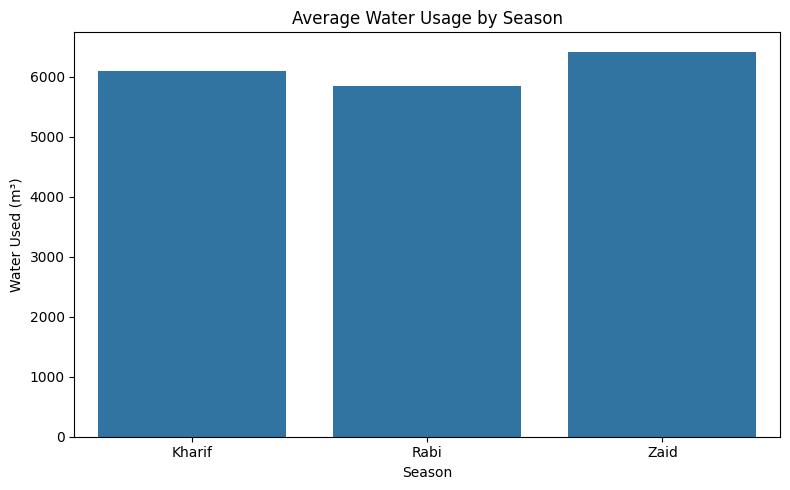

In [30]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Water_Used_m3',
    estimator='mean',
    errorbar=None
)

plt.title('Average Water Usage by Season')
plt.xlabel('Season')
plt.ylabel('Water Used (m³)')

plt.tight_layout()
plt.show()

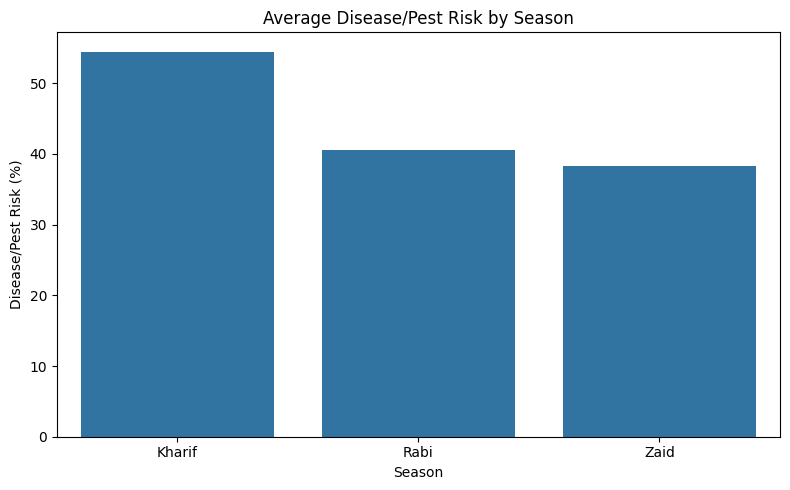

In [31]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Disease_Pest_Risk_pct',
    estimator='mean',
    errorbar=None
)

plt.title('Average Disease/Pest Risk by Season')
plt.xlabel('Season')
plt.ylabel('Disease/Pest Risk (%)')

plt.tight_layout()
plt.show()

In [32]:
print("Dataset Shape:", df.shape)

print("\n" + "="*60)
print("DATA TYPES")
print("="*60)
print(df.dtypes)

print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)

missing_report = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_report = missing_report[
    missing_report['Missing_Count'] > 0
].sort_values(
    by='Missing_Count',
    ascending=False
)

print(missing_report)

print("\n" + "="*60)
print("DUPLICATE ROWS")
print("="*60)

print("Duplicate rows:", df.duplicated().sum())

Dataset Shape: (4000, 28)

DATA TYPES
Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR        

In [33]:
checks = {
    'Farm_Area_Hectares <= 0': df['Farm_Area_Hectares'] <= 0,
    'Rainfall_mm < 0': df['Rainfall_mm'] < 0,
    'Humidity_pct outside 0-100':
        (df['Humidity_pct'] < 0) | (df['Humidity_pct'] > 100),
    'Sunlight_Hours_Day < 0':
        df['Sunlight_Hours_Day'] < 0,
    'Soil_pH outside 0-14':
        (df['Soil_pH'] < 0) | (df['Soil_pH'] > 14),
    'Soil_Moisture_pct outside 0-100':
        (df['Soil_Moisture_pct'] < 0) | (df['Soil_Moisture_pct'] > 100),
    'Nitrogen_kg_ha < 0':
        df['Nitrogen_kg_ha'] < 0,
    'Phosphorus_kg_ha < 0':
        df['Phosphorus_kg_ha'] < 0,
    'Potassium_kg_ha < 0':
        df['Potassium_kg_ha'] < 0,
    'Fertilizer_kg_ha < 0':
        df['Fertilizer_kg_ha'] < 0,
    'Pesticide_Litre_ha < 0':
        df['Pesticide_Litre_ha'] < 0,
    'Seed_Quality_Score outside 0-1':
        (df['Seed_Quality_Score'] < 0) |
        (df['Seed_Quality_Score'] > 1),
    'Yield_Tonnes_Ha < 0':
        df['Yield_Tonnes_Ha'] < 0,
    'Production_Tonnes < 0':
        df['Production_Tonnes'] < 0,
    'Market_Price_INR_Tonne < 0':
        df['Market_Price_INR_Tonne'] < 0,
    'Total_Cost_INR < 0':
        df['Total_Cost_INR'] < 0,
    'Revenue_INR < 0':
        df['Revenue_INR'] < 0,
    'Water_Used_m3 < 0':
        df['Water_Used_m3'] < 0,
    'Water_Efficiency_t_per_1000m3 < 0':
        df['Water_Efficiency_t_per_1000m3'] < 0,
    'Disease_Pest_Risk_pct outside 0-100':
        (df['Disease_Pest_Risk_pct'] < 0) |
        (df['Disease_Pest_Risk_pct'] > 100)
}

invalid_report = pd.DataFrame({
    'Invalid_Count': {
        name: condition.sum()
        for name, condition in checks.items()
    }
})

invalid_report = invalid_report[
    invalid_report['Invalid_Count'] > 0
]

invalid_report

,Invalid_Count


In [35]:
df['Calculated_Profit'] = (
    df['Revenue_INR'] - df['Total_Cost_INR']
)

df['Profit_Difference'] = (
    df['Profit_INR'] - df['Calculated_Profit']
)

print("Maximum absolute difference:")

print(
    df['Profit_Difference']
    .abs()
    .max()
)

print("\nNumber of inconsistent rows:")

print(
    (df['Profit_Difference'].abs() > 0.01).sum()
)

Maximum absolute difference:
0

Number of inconsistent rows:
0


In [36]:
df[
    df['Profit_Difference'].abs() > 0.01
][[
    'Revenue_INR',
    'Total_Cost_INR',
    'Profit_INR',
    'Calculated_Profit',
    'Profit_Difference'
]].head(20)

,Revenue_INR,Total_Cost_INR,Profit_INR,Calculated_Profit,Profit_Difference


In [37]:
df['Calculated_Production'] = (
    df['Farm_Area_Hectares'] *
    df['Yield_Tonnes_Ha']
)

df['Production_Difference'] = (
    df['Production_Tonnes'] -
    df['Calculated_Production']
)

production_check = pd.DataFrame({
    'Mean_Difference':
        [df['Production_Difference'].mean()],

    'Median_Difference':
        [df['Production_Difference'].median()],

    'Max_Absolute_Difference':
        [df['Production_Difference'].abs().max()],

    'Inconsistent_Rows':
        [(df['Production_Difference'].abs() > 0.01).sum()]
})

production_check

,Mean_Difference,Median_Difference,Max_Absolute_Difference,Inconsistent_Rows
0,0.000003,0.0,0.005,0


In [38]:
df[
    df['Production_Difference'].abs() > 0.01
][[
    'Farm_Area_Hectares',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Calculated_Production',
    'Production_Difference'
]].head(20)

,Farm_Area_Hectares,Yield_Tonnes_Ha,Production_Tonnes,Calculated_Production,Production_Difference


In [155]:
df['Calculated_Revenue'] = (
    df['Production_Tonnes'] *
    df['Market_Price_INR_Tonne']
)

df['Revenue_Difference'] = (
    df['Revenue_INR'] -
    df['Calculated_Revenue']
)

revenue_check = pd.DataFrame({
    'Mean_Difference':
        [df['Revenue_Difference'].mean()],

    'Median_Difference':
        [df['Revenue_Difference'].median()],

    'Max_Absolute_Difference':
        [df['Revenue_Difference'].abs().max()],

    'Inconsistent_Rows':
        [(df['Revenue_Difference'].abs() > 0.01).sum()]
})

revenue_check

,Mean_Difference,Median_Difference,Max_Absolute_Difference,Inconsistent_Rows
0,0.0018,0.0,0.5,3777


In [40]:
df[
    df['Revenue_Difference'].abs() > 0.01
][[
    'Production_Tonnes',
    'Market_Price_INR_Tonne',
    'Revenue_INR',
    'Calculated_Revenue',
    'Revenue_Difference'
]].head(20)

,Production_Tonnes,Market_Price_INR_Tonne,Revenue_INR,Calculated_Revenue,Revenue_Difference
1,1.96,20613,40401,40401.48,-0.48
2,2.53,75283,190466,190465.99,0.01
3,8.28,24244,200740,200740.32,-0.32
4,9.30,20818,193607,193607.40,-0.40
5,3.93,68593,269570,269570.49,-0.49
6,20.57,22951,472102,472102.07,-0.07
7,6.30,70042,441265,441264.60,0.40
8,10.68,70771,755834,755834.28,-0.28
9,31.35,94383,2958907,2958907.05,-0.05
10,6.77,20806,140857,140856.62,0.38


In [41]:
outlier_columns = [
    'Farm_Area_Hectares',
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

outlier_summary = []

for column in outlier_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ][column]

    outlier_summary.append({
        'Column': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Outlier_Count': len(outliers),
        'Outlier_Percentage': (len(outliers) / len(df)) * 100
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df.sort_values(
    by='Outlier_Count',
    ascending=False
)

,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,-148731.750,216187.75000,364919.50000,-696111.000000,7.635670e+05,404,10.100
14,Production_Tonnes,5.020,24.35500,19.33500,-23.982500,5.335750e+01,333,8.325
20,Water_Efficiency_t_per_1000m3,1.661,5.15025,3.48925,-3.572875,1.038412e+01,322,8.050
13,Yield_Tonnes_Ha,1.050,2.84000,1.79000,-1.635000,5.525000e+00,302,7.550
19,Water_Used_m3,2268.750,7829.75000,5561.00000,-6072.750000,1.617125e+04,276,6.900
17,Revenue_INR,207517.250,836874.75000,629357.50000,-736519.000000,1.780911e+06,240,6.000
9,Potassium_kg_ha,86.200,123.60000,37.40000,30.100000,1.797000e+02,32,0.800
4,Sunlight_Hours_Day,6.600,8.10000,1.50000,4.350000,1.035000e+01,26,0.650
8,Phosphorus_kg_ha,46.200,69.40000,23.20000,11.400000,1.042000e+02,16,0.400
10,Fertilizer_kg_ha,143.975,227.20000,83.22500,19.137500,3.520375e+02,15,0.375


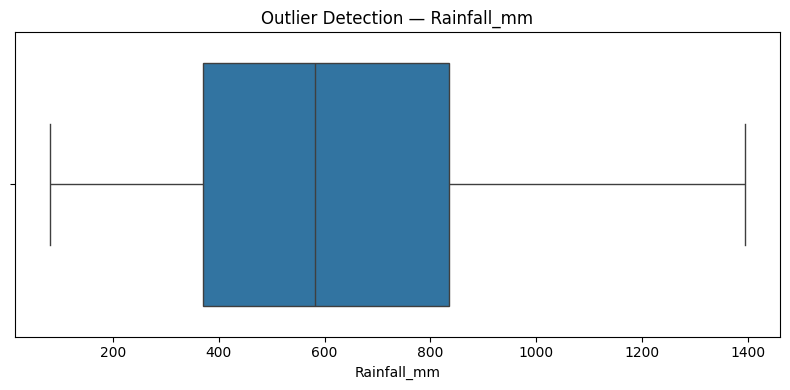

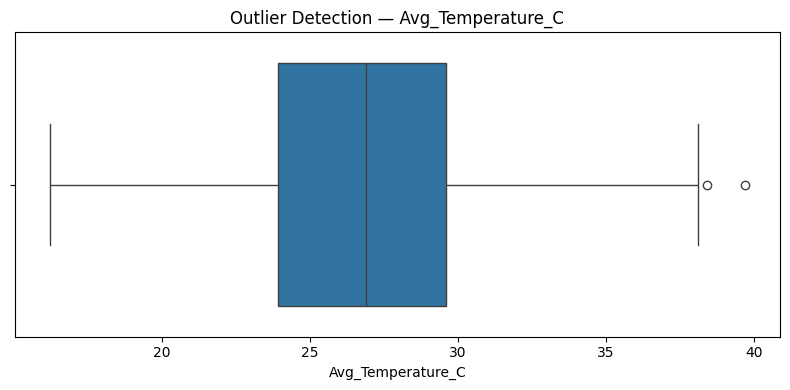

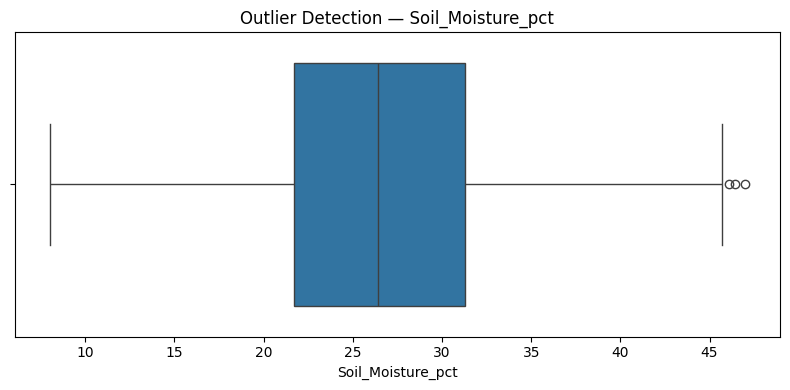

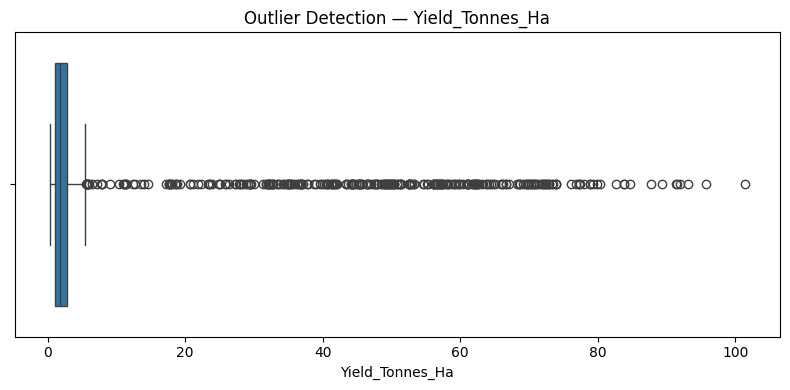

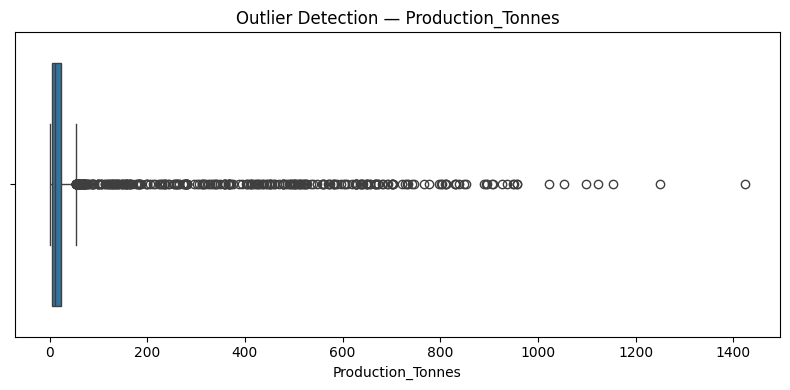

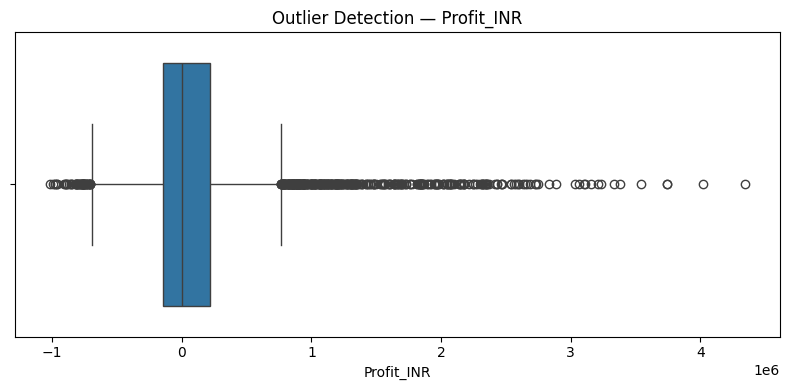

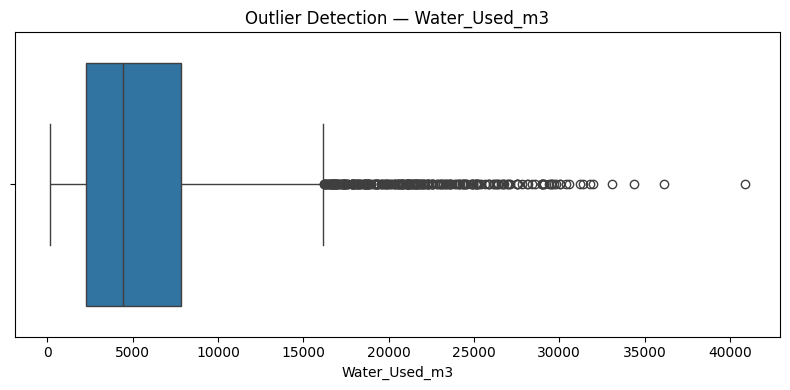

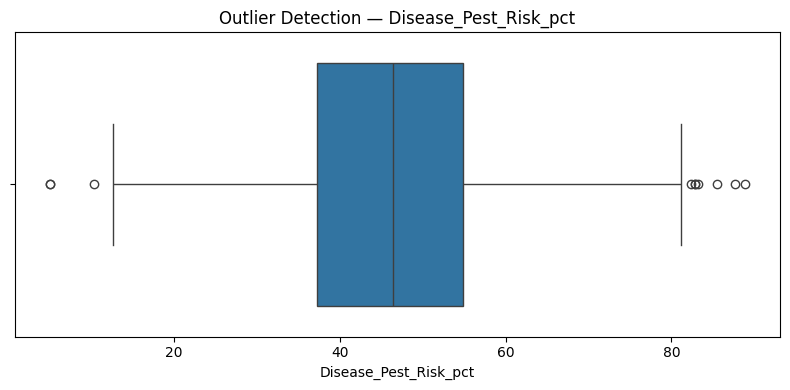

In [46]:
important_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Soil_Moisture_pct',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Profit_INR',
    'Water_Used_m3',
    'Disease_Pest_Risk_pct'
]

for column in important_columns:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=df[column]
    )

    plt.title(f'Outlier Detection — {column}')
    plt.xlabel(column)

    plt.tight_layout()
    plt.show()

In [45]:
print("Lowest Yield Farms:")
display(
    df[
        ['Farm_ID', 'State', 'District', 'Crop',
         'Season', 'Yield_Tonnes_Ha']
    ]
    .sort_values('Yield_Tonnes_Ha')
    .head(10)
)

print("\nHighest Yield Farms:")
display(
    df[
        ['Farm_ID', 'State', 'District', 'Crop',
         'Season', 'Yield_Tonnes_Ha']
    ]
    .sort_values('Yield_Tonnes_Ha', ascending=False)
    .head(10)
)

Lowest Yield Farms:


,Farm_ID,State,District,Crop,Season,Yield_Tonnes_Ha
3984,SF13985,Andhra Pradesh,Ludhiana,Rice,Kharif,0.3
3987,SF13988,Madhya Pradesh,Guntur,Pulses,Zaid,0.3
3977,SF13978,Telangana,Erode,Cotton,Kharif,0.3
51,SF10052,Andhra Pradesh,Rajkot,Pulses,Rabi,0.3
2783,SF12784,Tamil Nadu,Warangal,Pulses,Kharif,0.3
585,SF10586,Telangana,Warangal,Cotton,Zaid,0.3
595,SF10596,Maharashtra,Krishna,Cotton,Rabi,0.3
3781,SF13782,Punjab,Nalgonda,Wheat,Kharif,0.3
563,SF10564,Madhya Pradesh,Ludhiana,Chilli,Rabi,0.3
567,SF10568,Punjab,Nalgonda,Pulses,Kharif,0.3



Highest Yield Farms:


,Farm_ID,State,District,Crop,Season,Yield_Tonnes_Ha
1715,SF11716,Gujarat,Indore,Sugarcane,Kharif,101.44
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,95.79
3525,SF13526,Andhra Pradesh,Erode,Sugarcane,Rabi,93.13
1464,SF11465,Gujarat,Nashik,Sugarcane,Kharif,91.98
3523,SF13524,Karnataka,Nashik,Sugarcane,Kharif,91.46
2782,SF12783,Gujarat,Nalgonda,Sugarcane,Rabi,91.32
644,SF10645,Andhra Pradesh,Ludhiana,Sugarcane,Kharif,89.34
2847,SF12848,Telangana,Warangal,Sugarcane,Kharif,87.76
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,84.75
1178,SF11179,Karnataka,Nalgonda,Sugarcane,Kharif,83.79


In [44]:
print("Lowest Profit Farms:")
display(
    df[
        ['Farm_ID', 'State', 'District', 'Crop',
         'Season', 'Revenue_INR',
         'Total_Cost_INR', 'Profit_INR']
    ]
    .sort_values('Profit_INR')
    .head(10)
)

print("\nHighest Profit Farms:")
display(
    df[
        ['Farm_ID', 'State', 'District', 'Crop',
         'Season', 'Revenue_INR',
         'Total_Cost_INR', 'Profit_INR']
    ]
    .sort_values('Profit_INR', ascending=False)
    .head(10)
)

Lowest Profit Farms:


,Farm_ID,State,District,Crop,Season,Revenue_INR,Total_Cost_INR,Profit_INR
780,SF10781,Andhra Pradesh,Ludhiana,Groundnut,Rabi,280139,1299362,-1019223
2210,SF12211,Andhra Pradesh,Raichur,Wheat,Rabi,102497,1097692,-995195
3625,SF13626,Punjab,Krishna,Maize,Rabi,226503,1207553,-981050
2182,SF12183,Andhra Pradesh,Krishna,Rice,Kharif,320865,1297725,-976860
104,SF10105,Gujarat,Krishna,Wheat,Zaid,98792,1063989,-965197
3394,SF13395,Gujarat,Erode,Wheat,Kharif,99644,1063040,-963396
2730,SF12731,Madhya Pradesh,Ludhiana,Rice,Rabi,89197,995279,-906082
1311,SF11312,Punjab,Rajkot,Rice,Zaid,163084,1065824,-902740
585,SF10586,Telangana,Warangal,Cotton,Zaid,198300,1094030,-895730
3090,SF13091,Karnataka,Ludhiana,Maize,Kharif,109026,999667,-890641



Highest Profit Farms:


,Farm_ID,State,District,Crop,Season,Revenue_INR,Total_Cost_INR,Profit_INR
2236,SF12237,Punjab,Rajkot,Chilli,Kharif,5057448,712027,4345421
626,SF10627,Maharashtra,Warangal,Chilli,Kharif,5080900,1059050,4021850
3425,SF13426,Madhya Pradesh,Rajkot,Sugarcane,Kharif,4485260,745161,3740099
1690,SF11691,Karnataka,Warangal,Chilli,Kharif,4522464,784135,3738329
247,SF10248,Maharashtra,Krishna,Chilli,Kharif,4825365,1283161,3542204
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,4350998,972119,3378879
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,4428460,1097878,3330582
1930,SF11931,Tamil Nadu,Guntur,Sugarcane,Kharif,4108301,875331,3232970
3983,SF13984,Gujarat,Nashik,Chilli,Kharif,4055609,844264,3211345
263,SF10264,Maharashtra,Ludhiana,Chilli,Rabi,3987664,828217,3159447


In [48]:
missing_rows = df[
    df[['Rainfall_mm',
        'Soil_Moisture_pct',
        'Yield_Tonnes_Ha']]
    .isnull()
    .any(axis=1)
]

print("Rows containing missing values:", len(missing_rows))

display(
    missing_rows[
        ['Farm_ID', 'State', 'District',
         'Crop', 'Season',
         'Rainfall_mm',
         'Soil_Moisture_pct',
         'Yield_Tonnes_Ha']
    ].head(20)
)

Rows containing missing values: 120


,Farm_ID,State,District,Crop,Season,Rainfall_mm,Soil_Moisture_pct,Yield_Tonnes_Ha
28,SF10029,Tamil Nadu,Rajkot,Maize,Rabi,443.1,NaN,3.01
43,SF10044,Tamil Nadu,Erode,Wheat,Rabi,460.1,NaN,2.60
55,SF10056,Karnataka,Warangal,Groundnut,Rabi,167.3,21.8,NaN
121,SF10122,Maharashtra,Erode,Cotton,Kharif,896.1,NaN,0.30
163,SF10164,Madhya Pradesh,Erode,Pulses,Zaid,445.9,20.0,NaN
186,SF10187,Tamil Nadu,Indore,Rice,Rabi,NaN,30.0,2.41
196,SF10197,Andhra Pradesh,Raichur,Rice,Kharif,1118.6,NaN,3.08
253,SF10254,Tamil Nadu,Ludhiana,Sugarcane,Zaid,NaN,17.8,62.76
271,SF10272,Karnataka,Erode,Groundnut,Kharif,NaN,27.3,0.45
272,SF10273,Punjab,Rajkot,Maize,Rabi,NaN,18.5,2.25


In [50]:
missing_by_season = df.groupby('Season').agg(
    Rainfall_Missing=('Rainfall_mm', lambda x: x.isna().sum()),
    Soil_Moisture_Missing=('Soil_Moisture_pct', lambda x: x.isna().sum()),
    Yield_Missing=('Yield_Tonnes_Ha', lambda x: x.isna().sum())
)

missing_by_season

,Rainfall_Missing,Soil_Moisture_Missing,Yield_Missing
Season,,,
Kharif,19,18,7
Rabi,18,13,20
Zaid,11,9,5


In [51]:
missing_by_crop = df.groupby('Crop').agg(
    Rainfall_Missing=('Rainfall_mm', lambda x: x.isna().sum()),
    Soil_Moisture_Missing=('Soil_Moisture_pct', lambda x: x.isna().sum()),
    Yield_Missing=('Yield_Tonnes_Ha', lambda x: x.isna().sum())
)

missing_by_crop

,Rainfall_Missing,Soil_Moisture_Missing,Yield_Missing
Crop,,,
Chilli,4,3,5
Cotton,4,5,4
Groundnut,5,1,5
Maize,8,8,4
Pulses,6,2,2
Rice,10,7,8
Sugarcane,4,7,2
Wheat,7,7,2


In [52]:
missing_yield = df[
    df['Yield_Tonnes_Ha'].isnull()
].copy()

missing_yield['Calculated_Yield'] = (
    missing_yield['Production_Tonnes'] /
    missing_yield['Farm_Area_Hectares']
)

display(
    missing_yield[
        ['Farm_ID',
         'Farm_Area_Hectares',
         'Production_Tonnes',
         'Calculated_Yield',
         'Crop',
         'Season']
    ]
)

,Farm_ID,Farm_Area_Hectares,Production_Tonnes,Calculated_Yield,Crop,Season
55,SF10056,11.70,19.42,1.659829,Groundnut,Rabi
163,SF10164,3.55,1.06,0.298592,Pulses,Zaid
555,SF10556,7.94,15.64,1.969773,Chilli,Rabi
648,SF10649,6.14,8.66,1.410423,Groundnut,Rabi
650,SF10651,13.23,11.77,0.889645,Maize,Rabi
777,SF10778,1.83,2.42,1.322404,Cotton,Rabi
874,SF10875,3.15,3.87,1.228571,Rice,Kharif
899,SF10900,6.65,6.38,0.959398,Pulses,Rabi
1133,SF11134,10.89,15.46,1.419651,Cotton,Kharif
1251,SF11252,9.92,12.20,1.229839,Chilli,Zaid


In [53]:
df_clean = df.copy()

print("Original shape:", df.shape)
print("Cleaning copy shape:", df_clean.shape)

Original shape: (4000, 34)
Cleaning copy shape: (4000, 34)


In [54]:
rainfall_before = df_clean['Rainfall_mm'].isna().sum()

df_clean['Rainfall_mm'] = (
    df_clean
    .groupby(['State', 'Season'])['Rainfall_mm']
    .transform(
        lambda x: x.fillna(x.median())
    )
)

rainfall_after = df_clean['Rainfall_mm'].isna().sum()

print("Rainfall missing before:", rainfall_before)
print("Rainfall missing after:", rainfall_after)

Rainfall missing before: 48
Rainfall missing after: 0


In [55]:
df_clean['Rainfall_mm'] = (
    df_clean
    .groupby('Season')['Rainfall_mm']
    .transform(
        lambda x: x.fillna(x.median())
    )
)

print(
    "Remaining Rainfall missing:",
    df_clean['Rainfall_mm'].isna().sum()
)

Remaining Rainfall missing: 0


In [56]:
soil_before = df_clean['Soil_Moisture_pct'].isna().sum()

df_clean['Soil_Moisture_pct'] = (
    df_clean
    .groupby(['State', 'Season'])['Soil_Moisture_pct']
    .transform(
        lambda x: x.fillna(x.median())
    )
)

df_clean['Soil_Moisture_pct'] = (
    df_clean
    .groupby('Season')['Soil_Moisture_pct']
    .transform(
        lambda x: x.fillna(x.median())
    )
)

soil_after = df_clean['Soil_Moisture_pct'].isna().sum()

print("Soil moisture missing before:", soil_before)
print("Soil moisture missing after:", soil_after)

Soil moisture missing before: 40
Soil moisture missing after: 0


In [57]:
missing_yield_mask = (
    df_clean['Yield_Tonnes_Ha'].isna()
)

df_clean.loc[missing_yield_mask, 'Yield_Tonnes_Ha'] = (
    df_clean.loc[missing_yield_mask, 'Production_Tonnes'] /
    df_clean.loc[missing_yield_mask, 'Farm_Area_Hectares']
)

print(
    "Remaining missing Yield:",
    df_clean['Yield_Tonnes_Ha'].isna().sum()
)

Remaining missing Yield: 0


In [58]:
remaining_missing = pd.DataFrame({
    'Missing_Count': df_clean.isnull().sum(),
    'Missing_Percentage':
        (df_clean.isnull().sum() / len(df_clean)) * 100
})

remaining_missing = remaining_missing[
    remaining_missing['Missing_Count'] > 0
]

remaining_missing

,Missing_Count,Missing_Percentage
Calculated_Production,32,0.8
Production_Difference,32,0.8


In [59]:
temporary_columns = [
    'Calculated_Profit',
    'Profit_Difference',
    'Calculated_Production',
    'Production_Difference',
    'Calculated_Revenue',
    'Revenue_Difference'
]

df_clean.drop(
    columns=temporary_columns,
    errors='ignore',
    inplace=True
)

print("Clean dataset shape:", df_clean.shape)

Clean dataset shape: (4000, 28)


In [60]:
print("="*60)
print("FINAL DATA QUALITY REPORT")
print("="*60)

print("\nDataset Shape:")
print(df_clean.shape)

print("\nMissing Values:")
print(df_clean.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df_clean.duplicated().sum())

print("\nData Types:")
print(df_clean.dtypes)

FINAL DATA QUALITY REPORT

Dataset Shape:
(4000, 28)

Missing Values:
0

Duplicate Rows:
0

Data Types:
Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             

In [61]:
clean_file = "seasonal_agriculture_performance_clean.csv"

df_clean.to_csv(
    clean_file,
    index=False
)

print(f"Clean dataset saved as: {clean_file}")

Clean dataset saved as: seasonal_agriculture_performance_clean.csv


In [62]:
comparison = pd.DataFrame({
    'Metric': [
        'Rows',
        'Columns',
        'Missing Values',
        'Duplicate Rows'
    ],

    'Before Cleaning': [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ],

    'After Cleaning': [
        df_clean.shape[0],
        df_clean.shape[1],
        df_clean.isnull().sum().sum(),
        df_clean.duplicated().sum()
    ]
})

comparison

,Metric,Before Cleaning,After Cleaning
0,Rows,4000,4000
1,Columns,34,28
2,Missing Values,184,0
3,Duplicate Rows,0,0


In [63]:
comparison = pd.DataFrame({
    'Metric': [
        'Rows',
        'Columns',
        'Missing Values',
        'Duplicate Rows'
    ],

    'Before Cleaning': [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ],

    'After Cleaning': [
        df_clean.shape[0],
        df_clean.shape[1],
        df_clean.isnull().sum().sum(),
        df_clean.duplicated().sum()
    ]
})

comparison

,Metric,Before Cleaning,After Cleaning
0,Rows,4000,4000
1,Columns,34,28
2,Missing Values,184,0
3,Duplicate Rows,0,0


In [64]:
cleaning_summary = {
    'Original_Rows': len(df),
    'Original_Columns': len(df.columns),
    'Missing_Values_Before': df.isnull().sum().sum(),
    'Missing_Values_After': df_clean.isnull().sum().sum(),
    'Duplicate_Rows_Before': df.duplicated().sum(),
    'Duplicate_Rows_After': df_clean.duplicated().sum()
}

for key, value in cleaning_summary.items():
    print(f"{key}: {value}")

Original_Rows: 4000
Original_Columns: 34
Missing_Values_Before: 184
Missing_Values_After: 0
Duplicate_Rows_Before: 0
Duplicate_Rows_After: 0


In [65]:
season_distribution = (
    df_clean['Season']
    .value_counts()
    .reset_index()
)

season_distribution.columns = [
    'Season',
    'Farm_Count'
]

season_distribution

,Season,Farm_Count
0,Kharif,1779
1,Rabi,1627
2,Zaid,594


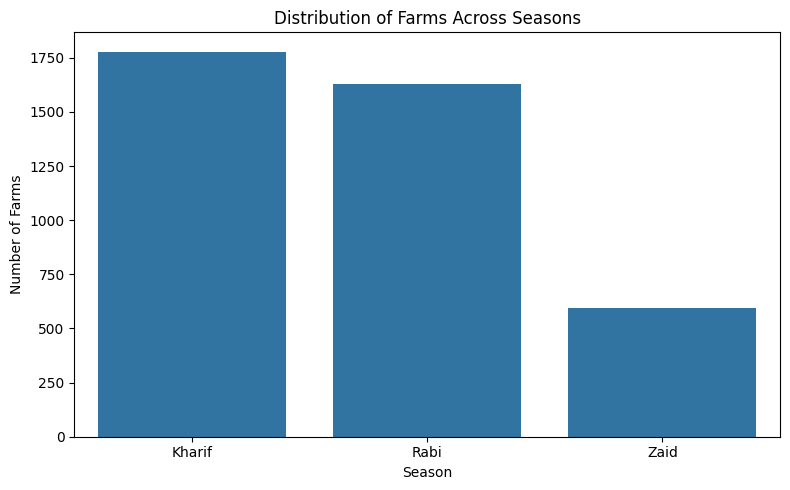

In [66]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=season_distribution,
    x='Season',
    y='Farm_Count'
)

plt.title('Distribution of Farms Across Seasons')
plt.xlabel('Season')
plt.ylabel('Number of Farms')

plt.tight_layout()
plt.show()

In [67]:
crop_distribution = (
    df_clean['Crop']
    .value_counts()
    .reset_index()
)

crop_distribution.columns = [
    'Crop',
    'Farm_Count'
]

crop_distribution

,Crop,Farm_Count
0,Rice,690
1,Wheat,614
2,Maize,551
3,Cotton,508
4,Pulses,496
5,Groundnut,424
6,Chilli,412
7,Sugarcane,305


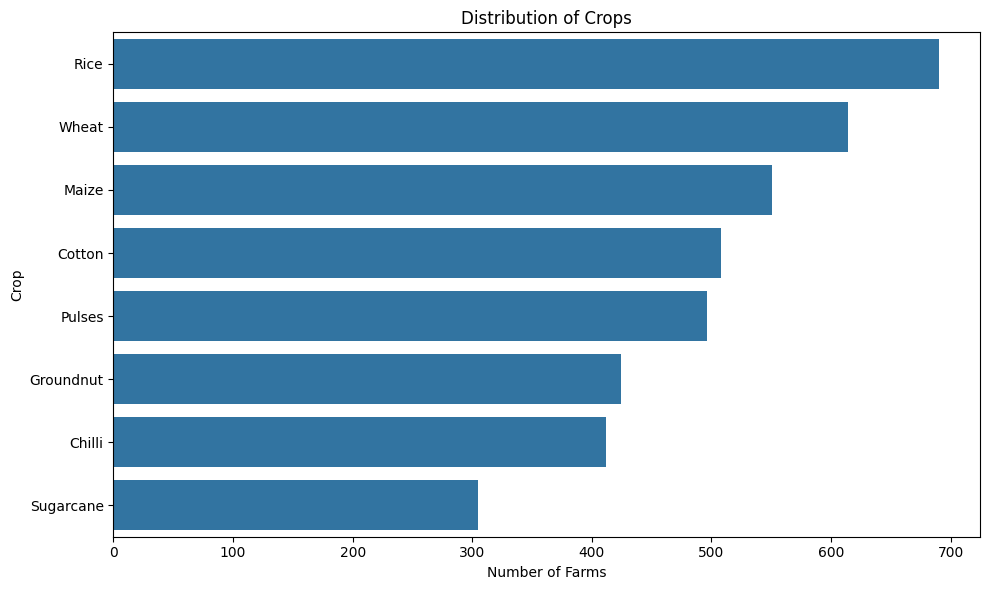

In [68]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=crop_distribution,
    y='Crop',
    x='Farm_Count'
)

plt.title('Distribution of Crops')
plt.xlabel('Number of Farms')
plt.ylabel('Crop')

plt.tight_layout()
plt.show()

In [69]:
crop_season_counts = pd.crosstab(
    df_clean['Crop'],
    df_clean['Season']
)

crop_season_counts

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,185,163,64
Cotton,215,201,92
Groundnut,193,177,54
Maize,234,233,84
Pulses,221,213,62
Rice,314,274,102
Sugarcane,125,129,51
Wheat,292,237,85


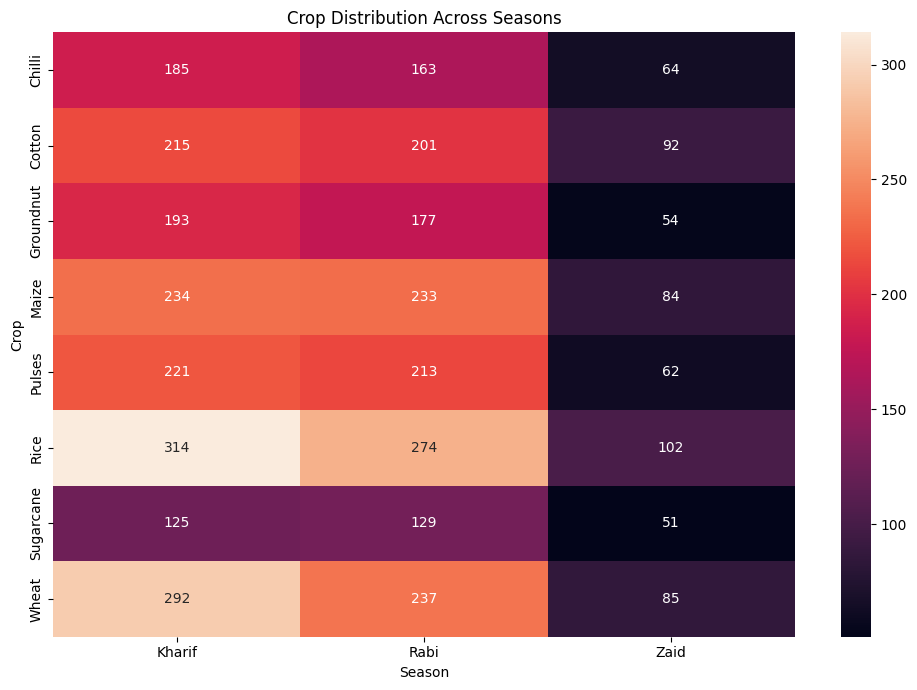

In [70]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    crop_season_counts,
    annot=True,
    fmt='d'
)

plt.title('Crop Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.tight_layout()
plt.show()

In [71]:
environmental_summary = df_clean.groupby('Season').agg({

    'Rainfall_mm': 'mean',

    'Avg_Temperature_C': 'mean',

    'Humidity_pct': 'mean',

    'Sunlight_Hours_Day': 'mean',

    'Soil_pH': 'mean',

    'Soil_Moisture_pct': 'mean'

}).round(2)

environmental_summary

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct
Season,,,,,,
Kharif,852.11,28.45,71.81,6.79,6.73,31.20
Rabi,435.93,23.49,57.89,7.59,6.67,24.05
Zaid,299.34,31.04,52.01,8.18,6.69,19.17


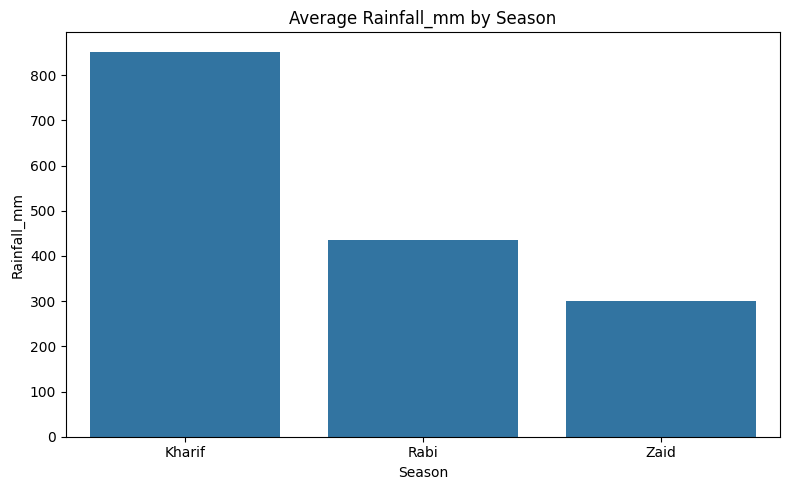

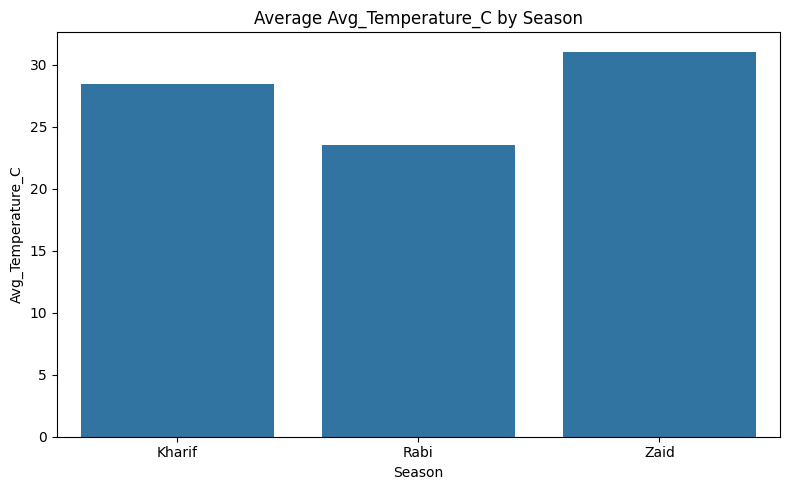

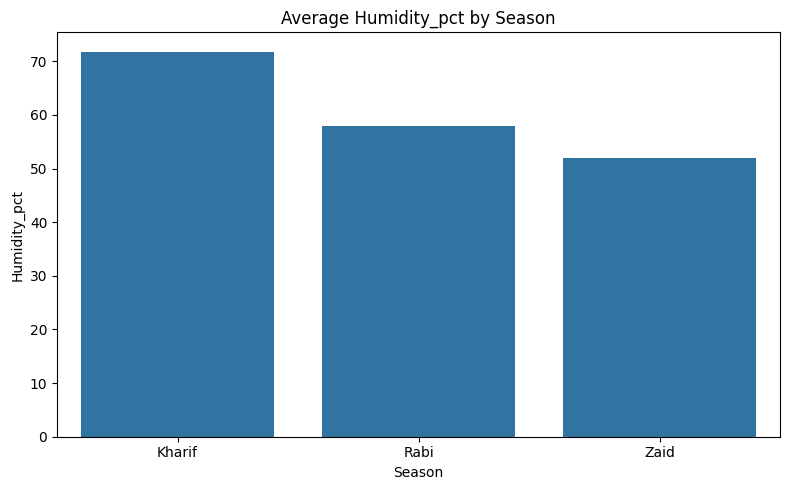

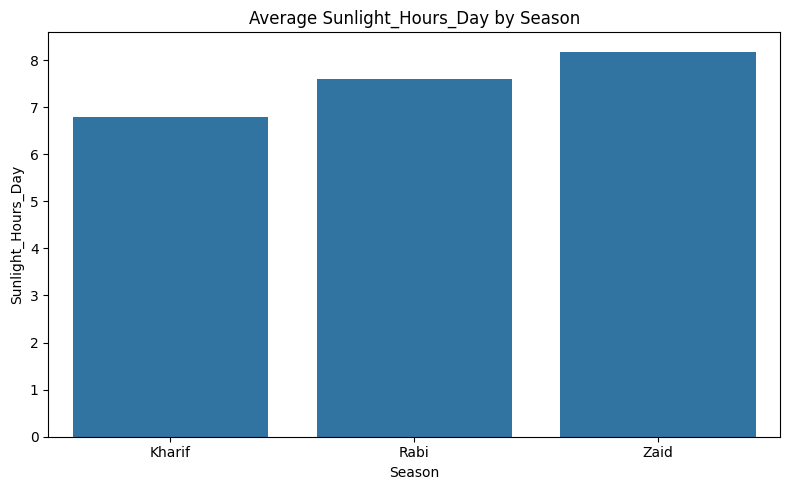

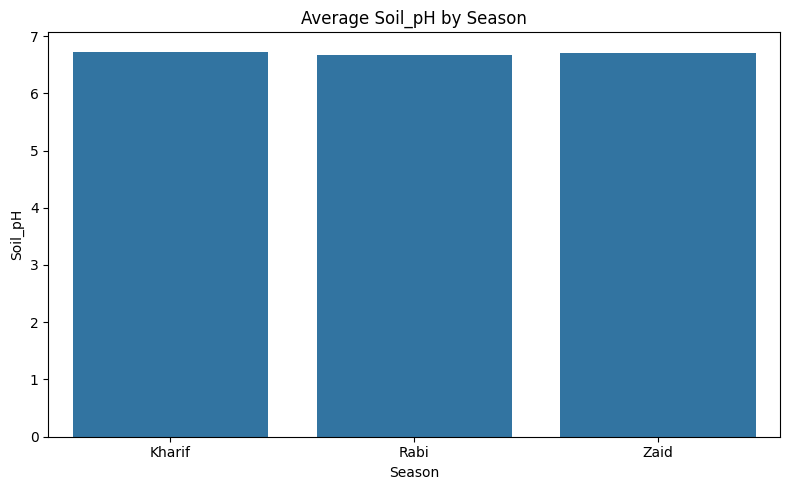

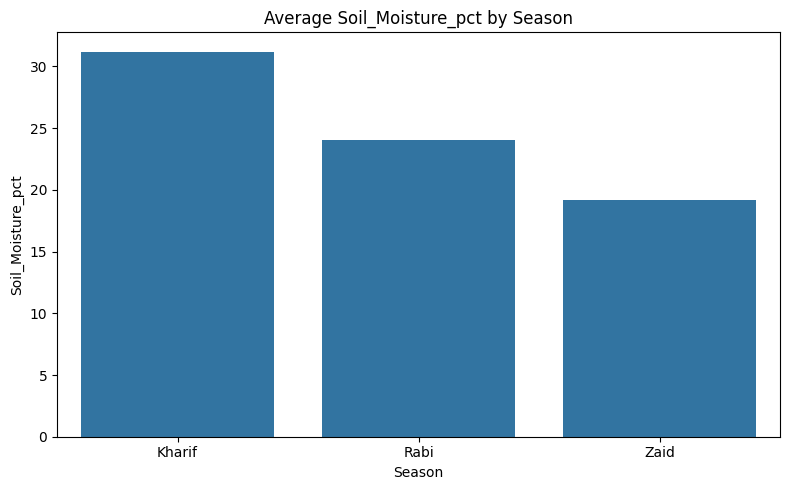

In [72]:
environmental_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct'
]

for column in environmental_columns:

    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=df_clean,
        x='Season',
        y=column,
        estimator='mean',
        errorbar=None
    )

    plt.title(f'Average {column} by Season')
    plt.xlabel('Season')
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()

In [73]:
resource_summary = df_clean.groupby('Season').agg({

    'Nitrogen_kg_ha': 'mean',

    'Phosphorus_kg_ha': 'mean',

    'Potassium_kg_ha': 'mean',

    'Fertilizer_kg_ha': 'mean',

    'Pesticide_Litre_ha': 'mean',

    'Water_Used_m3': 'mean'

}).round(2)

resource_summary

,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3
Season,,,,,,
Kharif,120.02,58.10,105.30,187.08,5.08,6102.20
Rabi,120.40,57.31,103.93,185.41,5.02,5846.99
Zaid,120.53,58.13,105.42,184.64,5.17,6419.89


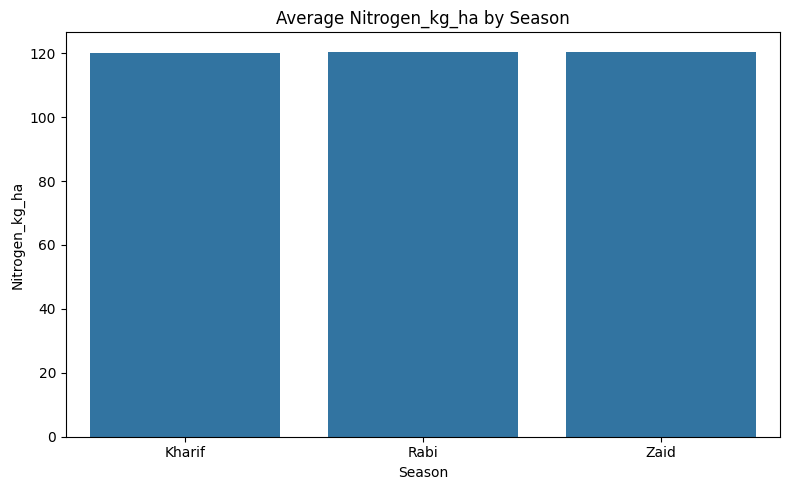

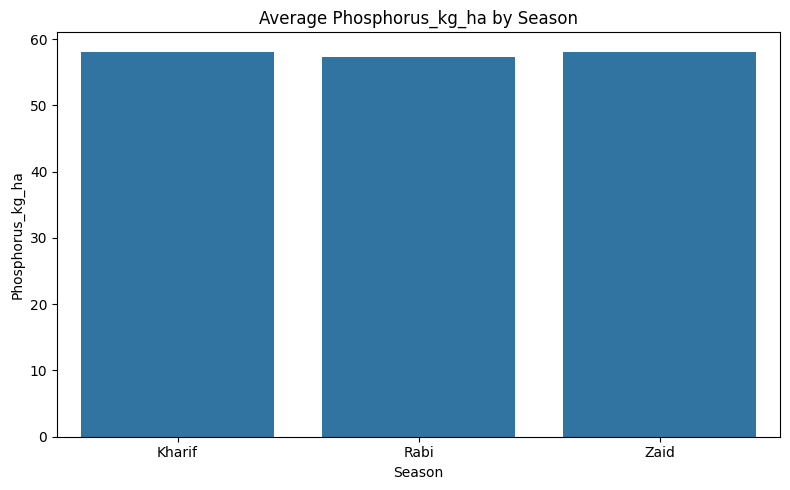

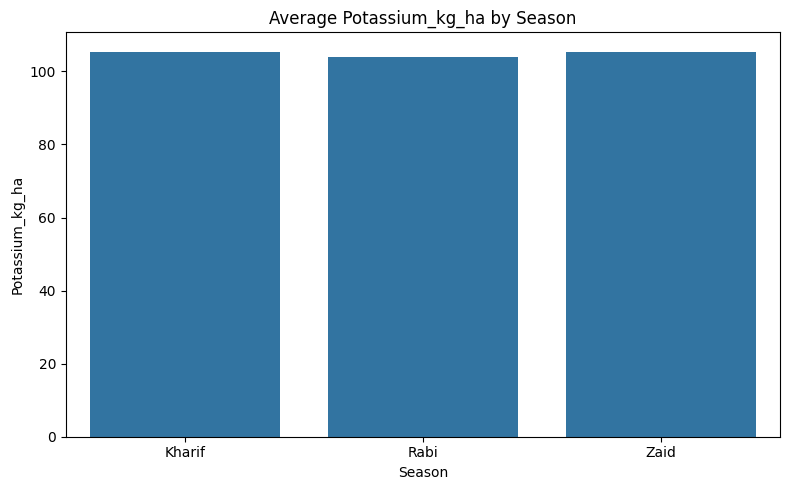

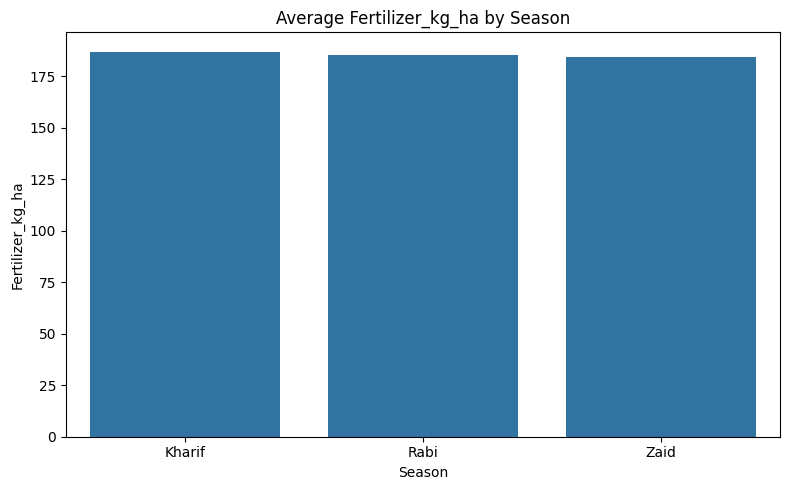

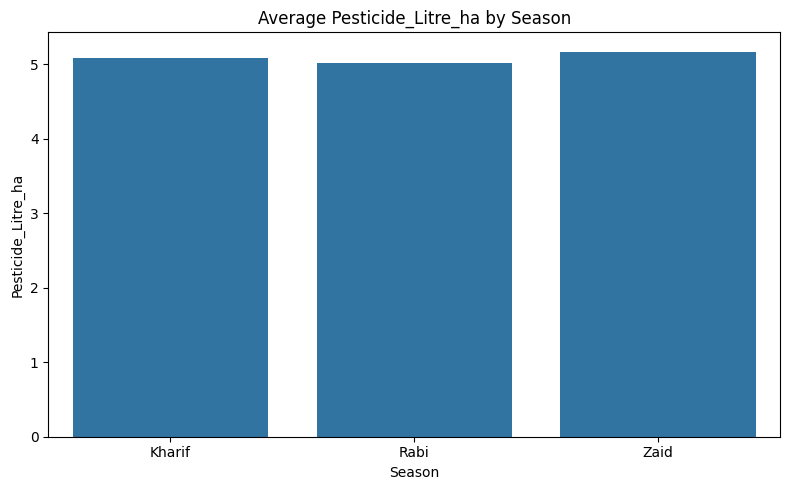

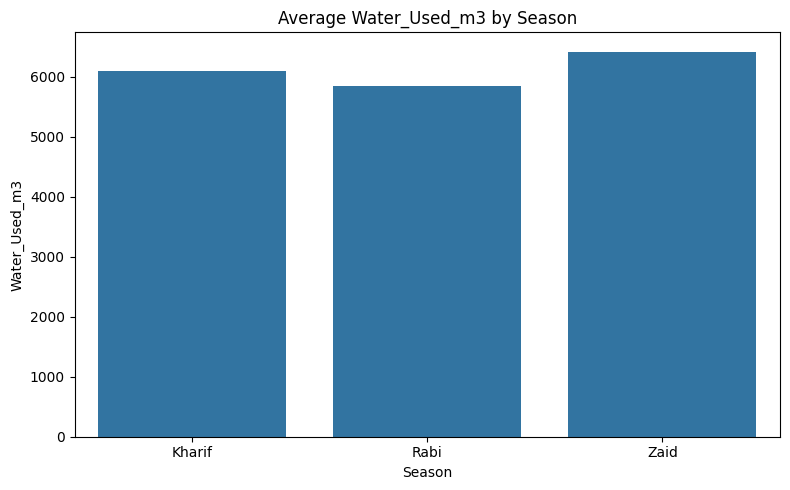

In [74]:
resource_columns = [
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Water_Used_m3'
]

for column in resource_columns:

    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=df_clean,
        x='Season',
        y=column,
        estimator='mean',
        errorbar=None
    )

    plt.title(f'Average {column} by Season')
    plt.xlabel('Season')
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()

In [75]:
irrigation_season = pd.crosstab(
    df_clean['Season'],
    df_clean['Irrigation_Method'],
    normalize='index'
) * 100

irrigation_season.round(2)

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.77,33.16,26.03,18.04
Rabi,22.74,32.33,26.92,18.01
Zaid,23.57,32.66,23.57,20.20


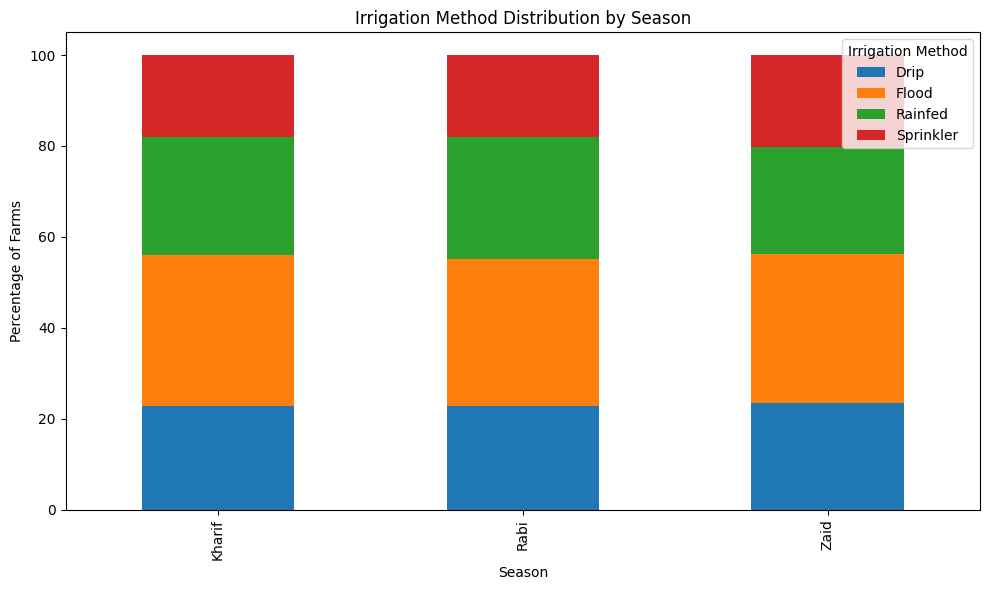

In [76]:
irrigation_season.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Irrigation Method Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Percentage of Farms')
plt.legend(title='Irrigation Method')

plt.tight_layout()
plt.show()

In [77]:
yield_summary = df_clean.groupby('Season').agg({

    'Yield_Tonnes_Ha': [
        'mean',
        'median',
        'min',
        'max',
        'std'
    ]

}).round(2)

yield_summary

Yield_Tonnes_Ha                           
                  mean median  min     max    std
Season                                           
Kharif            5.63   1.94  0.3  101.44  14.39
Rabi              5.09   1.66  0.3   93.13  12.83
Zaid              4.63   1.45  0.3   64.76  11.28

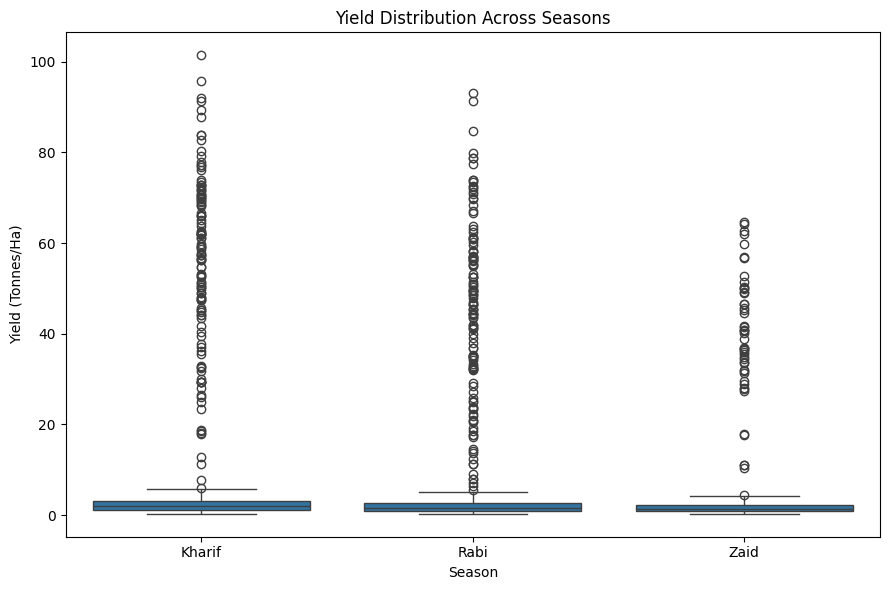

In [78]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_clean,
    x='Season',
    y='Yield_Tonnes_Ha'
)

plt.title('Yield Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

In [79]:
production_summary = df_clean.groupby('Season').agg({

    'Production_Tonnes': [
        'mean',
        'median',
        'sum'
    ]

}).round(2)

production_summary

Production_Tonnes                 
                    mean median       sum
Season                                   
Kharif             46.31  13.24  82387.61
Rabi               41.49  11.08  67498.88
Zaid               38.89   9.97  23098.35

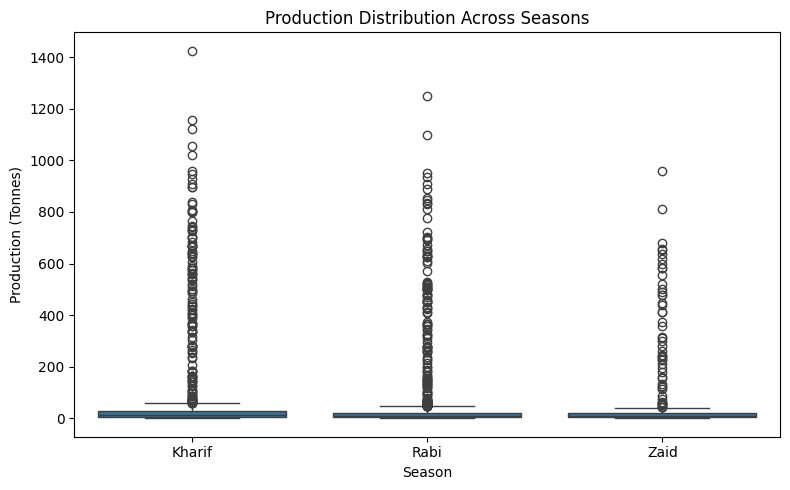

In [80]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x='Season',
    y='Production_Tonnes'
)

plt.title('Production Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Production (Tonnes)')

plt.tight_layout()
plt.show()

In [81]:
economic_summary = df_clean.groupby('Season').agg({

    'Market_Price_INR_Tonne': 'mean',

    'Total_Cost_INR': 'mean',

    'Revenue_INR': 'mean',

    'Profit_INR': 'mean'

}).round(2)

economic_summary

,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,,
Kharif,44850.91,531804.41,710719.06,178914.65
Rabi,44747.97,513836.58,601526.05,87689.47
Zaid,44212.03,543976.73,519171.90,-24804.82


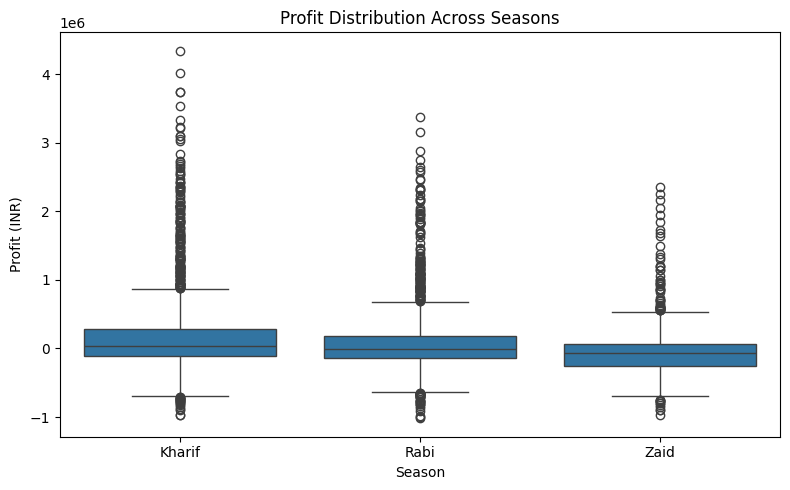

In [82]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x='Season',
    y='Profit_INR'
)

plt.title('Profit Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')

plt.tight_layout()
plt.show()

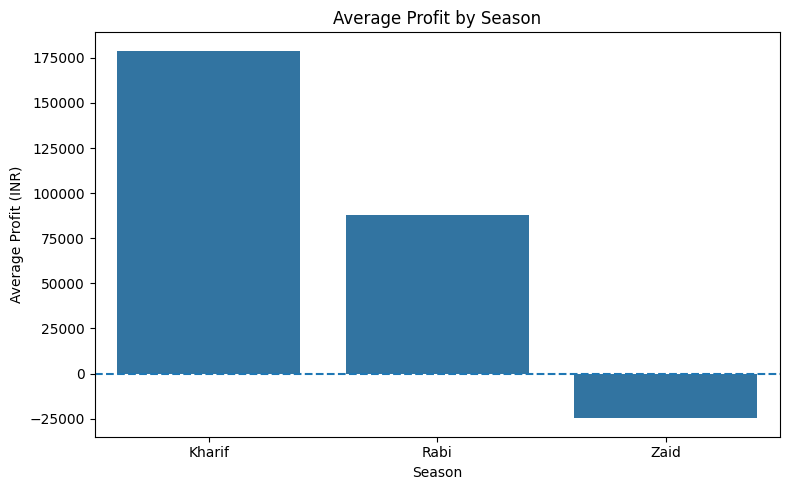

In [83]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Profit_INR',
    estimator='mean',
    errorbar=None
)

plt.axhline(
    0,
    linestyle='--'
)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

plt.tight_layout()
plt.show()

In [84]:
water_summary = df_clean.groupby('Season').agg({

    'Water_Used_m3': [
        'mean',
        'median'
    ],

    'Water_Efficiency_t_per_1000m3': [
        'mean',
        'median'
    ]

}).round(2)

water_summary

Water_Used_m3         Water_Efficiency_t_per_1000m3       
                mean  median                          mean median
Season                                                           
Kharif       6102.20  4469.0                          5.89   3.28
Rabi         5846.99  4292.0                          5.19   2.74
Zaid         6419.89  4805.0                          4.41   2.30

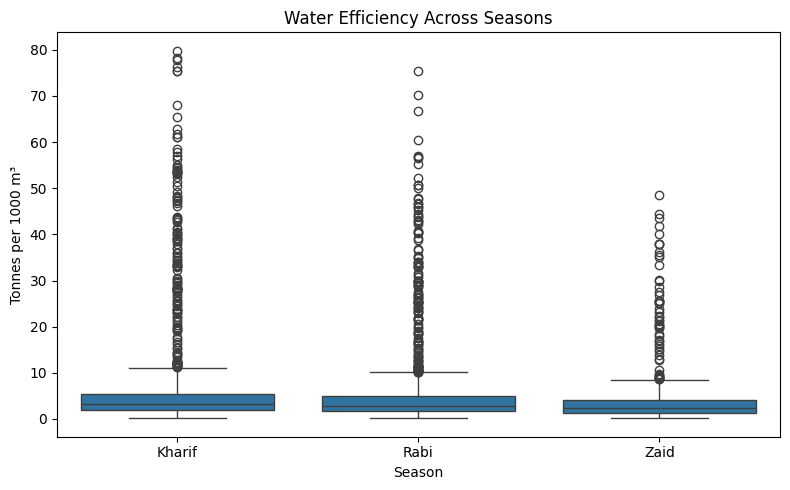

In [85]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x='Season',
    y='Water_Efficiency_t_per_1000m3'
)

plt.title('Water Efficiency Across Seasons')
plt.xlabel('Season')
plt.ylabel('Tonnes per 1000 m³')

plt.tight_layout()
plt.show()

In [86]:
risk_summary = df_clean.groupby('Season').agg({

    'Disease_Pest_Risk_pct': [
        'mean',
        'median',
        'min',
        'max'
    ]

}).round(2)

risk_summary

Disease_Pest_Risk_pct                   
                        mean median   min   max
Season                                         
Kharif                 54.47   54.5  21.3  88.9
Rabi                   40.48   40.6   5.1  71.2
Zaid                   38.22   37.9   5.0  71.6

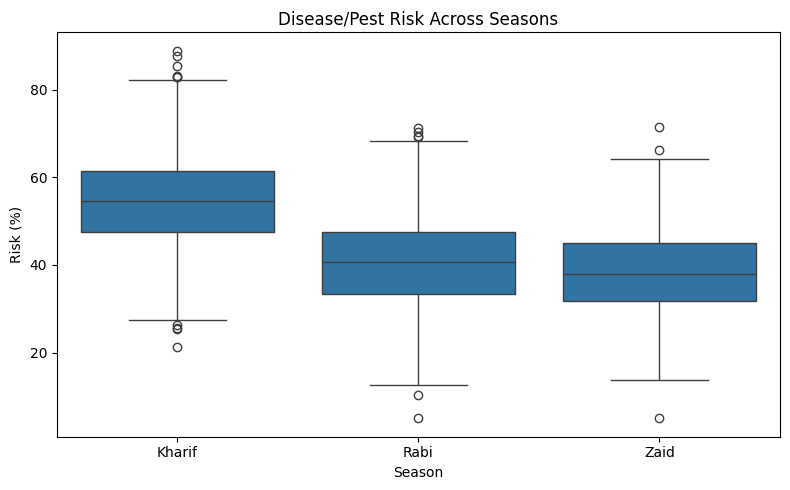

In [87]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x='Season',
    y='Disease_Pest_Risk_pct'
)

plt.title('Disease/Pest Risk Across Seasons')
plt.xlabel('Season')
plt.ylabel('Risk (%)')

plt.tight_layout()
plt.show()

In [88]:
seasonal_performance = df_clean.groupby('Season').agg({

    'Farm_Area_Hectares': 'mean',

    'Rainfall_mm': 'mean',

    'Avg_Temperature_C': 'mean',

    'Soil_Moisture_pct': 'mean',

    'Yield_Tonnes_Ha': 'mean',

    'Production_Tonnes': 'mean',

    'Total_Cost_INR': 'mean',

    'Revenue_INR': 'mean',

    'Profit_INR': 'mean',

    'Water_Used_m3': 'mean',

    'Water_Efficiency_t_per_1000m3': 'mean',

    'Disease_Pest_Risk_pct': 'mean'

}).round(2)

seasonal_performance

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Soil_Moisture_pct,Yield_Tonnes_Ha,Production_Tonnes,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,,,,,
Kharif,7.94,852.11,28.45,31.20,5.63,46.31,531804.41,710719.06,178914.65,6102.20,5.89,54.47
Rabi,7.75,435.93,23.49,24.05,5.09,41.49,513836.58,601526.05,87689.47,5846.99,5.19,40.48
Zaid,8.09,299.34,31.04,19.17,4.63,38.89,543976.73,519171.90,-24804.82,6419.89,4.41,38.22


In [89]:
season_crop_performance = (
    df_clean
    .groupby(['Season', 'Crop'])
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Avg_Production=('Production_Tonnes', 'mean'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Water_Efficiency=(
            'Water_Efficiency_t_per_1000m3',
            'mean'
        ),
        Avg_Disease_Risk=(
            'Disease_Pest_Risk_pct',
            'mean'
        )
    )
    .round(2)
)

season_crop_performance

Farms  Avg_Yield  Avg_Production  Avg_Profit  \
Season Crop                                                      
Kharif Chilli       185       1.73           14.46   954380.42   
       Cotton       215       1.37           10.41   216999.55   
       Groundnut    193       1.48           10.49   108265.44   
       Maize        234       2.97           23.35   -39332.67   
       Pulses       221       1.04            8.29    43338.90   
       Rice         314       2.71           22.45   -64903.40   
       Sugarcane    125      53.46          446.07  1000790.81   
       Wheat        292       2.25           18.31  -105871.87   
Rabi   Chilli       163       1.46           10.97   638572.50   
       Cotton       201       1.19            9.44   107343.59   
       Groundnut    177       1.23            9.06    10416.54   
       Maize        233       2.62           21.59   -89133.40   
       Pulses       213       0.87            7.20   -14309.14   
       Rice         274       2.33           17.22   -98427.87   
       Sugarcane    129      43.95          365.26   731612.86   
       Wheat        237       2.06           16.07  -119954.57   
Zaid   Chilli        64       1.18            9.98   448659.09   
       Cotton        92       0.94            6.93   -53925.34   
       Groundnut     54       1.04            8.62   -68872.50   
       Maize         84       2.28           17.94  -194049.17   
       Pulses        62       0.65            4.94  -139227.81   
       Rice         102       1.90           15.11  -227239.34   
       Sugarcane     51      38.42          329.56   583635.80   
       Wheat         85       1.75           14.06  -193208.95   

                  Avg_Water_Efficiency  Avg_Disease_Risk  
Season Crop                                               
Kharif Chilli                     3.26             52.81  
       Cotton                     2.13             54.24  
       Groundnut                  3.58             54.28  
       Maize                      6.05             54.82  
       Pulses                     3.35             54.96  
       Rice                       2.17             54.25  
       Sugarcane                 36.00             54.02  
       Wheat                      4.76             55.58  
Rabi   Chilli                     2.89             40.59  
       Cotton                     1.94             41.54  
       Groundnut                  2.90             39.76  
       Maize                      5.46             39.41  
       Pulses                     2.70             40.08  
       Rice                       1.84             40.79  
       Sugarcane                 27.92             39.85  
       Wheat                      4.69             41.46  
Zaid   Chilli                     2.20             40.50  
       Cotton                     1.49             36.34  
       Groundnut                  2.47             39.13  
       Maize                      4.75             36.68  
       Pulses                     1.95             38.97  
       Rice                       1.53             37.95  
       Sugarcane                 23.39             38.35  
       Wheat                      4.02             39.16

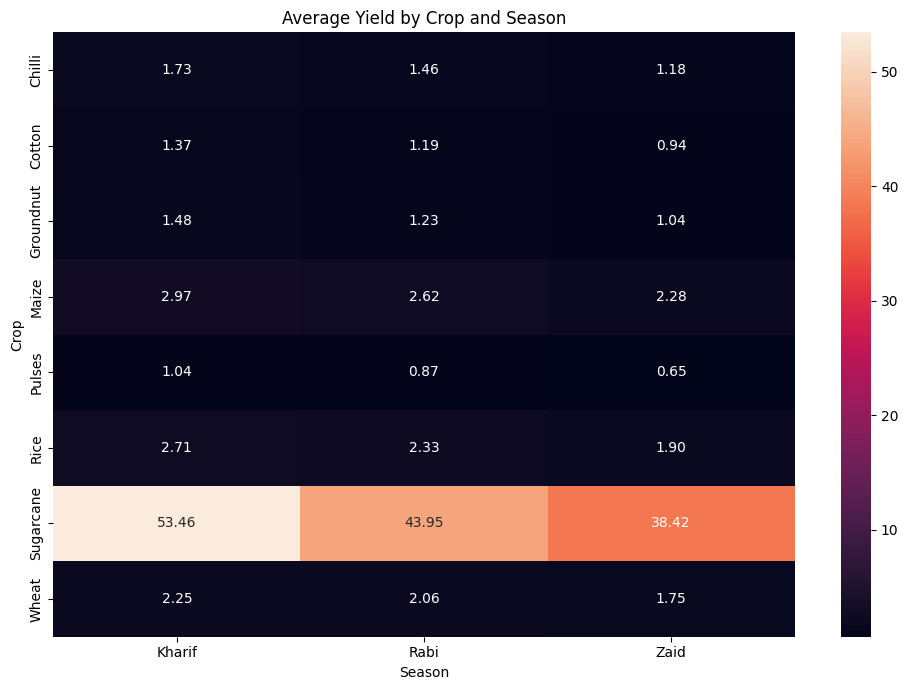

In [90]:
yield_heatmap = df_clean.pivot_table(
    index='Crop',
    columns='Season',
    values='Yield_Tonnes_Ha',
    aggfunc='mean'
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    yield_heatmap,
    annot=True,
    fmt='.2f'
)

plt.title('Average Yield by Crop and Season')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.tight_layout()
plt.show()

In [91]:
state_season_performance = (
    df_clean
    .groupby(['State', 'Season'])
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Water_Used=('Water_Used_m3', 'mean'),
        Avg_Water_Efficiency=(
            'Water_Efficiency_t_per_1000m3',
            'mean'
        )
    )
    .round(2)
)

state_season_performance

Farms  Avg_Yield  Avg_Profit  Avg_Water_Used  \
State          Season                                                 
Andhra Pradesh Kharif    240       5.68   169315.52         6598.72   
               Rabi      204       3.47    26315.71         4872.34   
               Zaid       85       4.45   -84084.87         7379.21   
Gujarat        Kharif    221       6.34   217051.33         6227.48   
               Rabi      200       5.70    82846.20         6018.77   
               Zaid       67       4.05  -106929.61         6231.52   
Karnataka      Kharif    209       6.45   201226.21         6980.67   
               Rabi      206       4.73    70952.61         5709.81   
               Zaid       74       6.62    23310.91         6776.00   
Madhya Pradesh Kharif    226       5.99   134242.40         5391.38   
               Rabi      208       3.75    61576.26         5894.84   
               Zaid       63       5.46      209.70         5879.19   
Maharashtra    Kharif    222       5.43   168801.05         5887.46   
               Rabi      218       5.50   159581.50         6090.03   
               Zaid       72       2.26   -40597.60         5847.43   
Punjab         Kharif    221       4.10   133779.10         5817.56   
               Rabi      186       8.61   169294.52         7415.02   
               Zaid       77       5.91    62109.69         6662.70   
Tamil Nadu     Kharif    206       5.52   211303.96         6117.74   
               Rabi      208       4.49    70456.86         5188.76   
               Zaid       71       4.10   -15175.20         6499.48   
Telangana      Kharif    234       5.55   199668.38         5835.40   
               Rabi      197       4.82    62824.60         5720.34   
               Zaid       85       4.24   -34620.78         5898.27   

                       Avg_Water_Efficiency  
State          Season                        
Andhra Pradesh Kharif                  6.12  
               Rabi                    4.16  
               Zaid                    4.07  
Gujarat        Kharif                  6.38  
               Rabi                    5.18  
               Zaid                    4.10  
Karnataka      Kharif                  5.89  
               Rabi                    5.33  
               Zaid                    5.30  
Madhya Pradesh Kharif                  6.22  
               Rabi                    4.34  
               Zaid                    4.90  
Maharashtra    Kharif                  5.63  
               Rabi                    5.67  
               Zaid                    3.05  
Punjab         Kharif                  4.98  
               Rabi                    6.68  
               Zaid                    4.92  
Tamil Nadu     Kharif                  6.07  
               Rabi                    4.95  
               Zaid                    4.13  
Telangana      Kharif                  5.83  
               Rabi                    5.32  
               Zaid                    4.80

In [92]:
irrigation_performance = (
    df_clean
    .groupby(['Season', 'Irrigation_Method'])
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Water_Used=('Water_Used_m3', 'mean'),
        Avg_Water_Efficiency=(
            'Water_Efficiency_t_per_1000m3',
            'mean'
        )
    )
    .round(2)
)

irrigation_performance

Farms  Avg_Yield  Avg_Profit  Avg_Water_Used  \
Season Irrigation_Method                                                 
Kharif Drip                 405       7.26   317222.07         5953.37   
       Flood                590       4.98   133373.83         8229.27   
       Rainfed              463       5.70   158974.13         3687.52   
       Sprinkler            321       4.67   116880.49         5863.27   
Rabi   Drip                 370       6.35   187843.22         5911.41   
       Flood                526       5.06    58824.80         7766.83   
       Rainfed              438       3.93    45232.48         3298.29   
       Sprinkler            293       5.30    76502.07         6129.09   
Zaid   Drip                 140       5.85    21291.84         5837.99   
       Flood                194       3.97   -69786.78         8113.69   
       Rainfed              140       3.06   -79467.26         3879.39   
       Sprinkler            120       6.13    57909.40         7324.41   

                          Avg_Water_Efficiency  
Season Irrigation_Method                        
Kharif Drip                               6.80  
       Flood                              3.64  
       Rainfed                            8.85  
       Sprinkler                          4.62  
Rabi   Drip                               6.05  
       Flood                              3.48  
       Rainfed                            6.87  
       Sprinkler                          4.64  
Zaid   Drip                               5.30  
       Flood                              2.73  
       Rainfed                            5.48  
       Sprinkler                          4.86

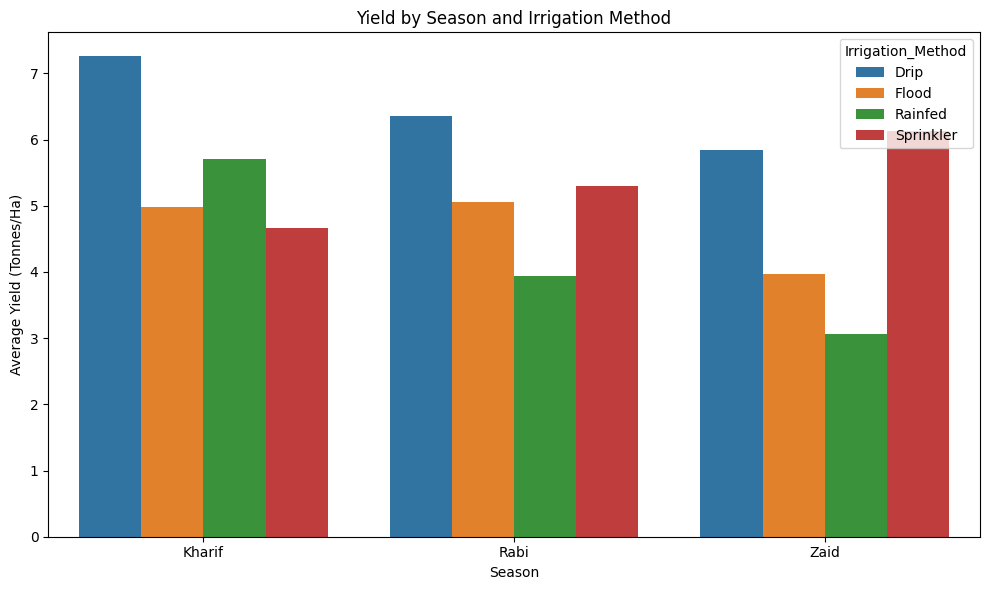

In [93]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Yield_Tonnes_Ha',
    hue='Irrigation_Method',
    estimator='mean',
    errorbar=None
)

plt.title('Yield by Season and Irrigation Method')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

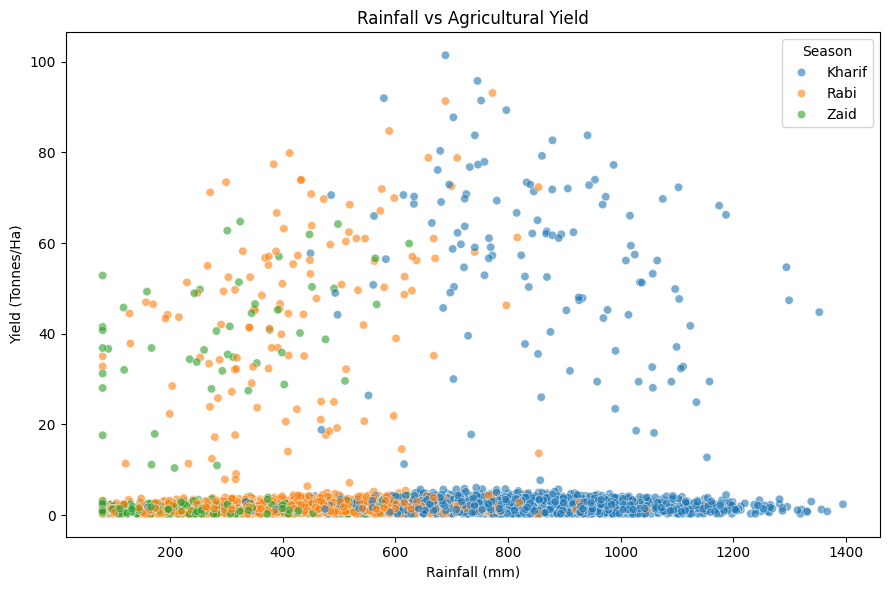

In [94]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season',
    alpha=0.6
)

plt.title('Rainfall vs Agricultural Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

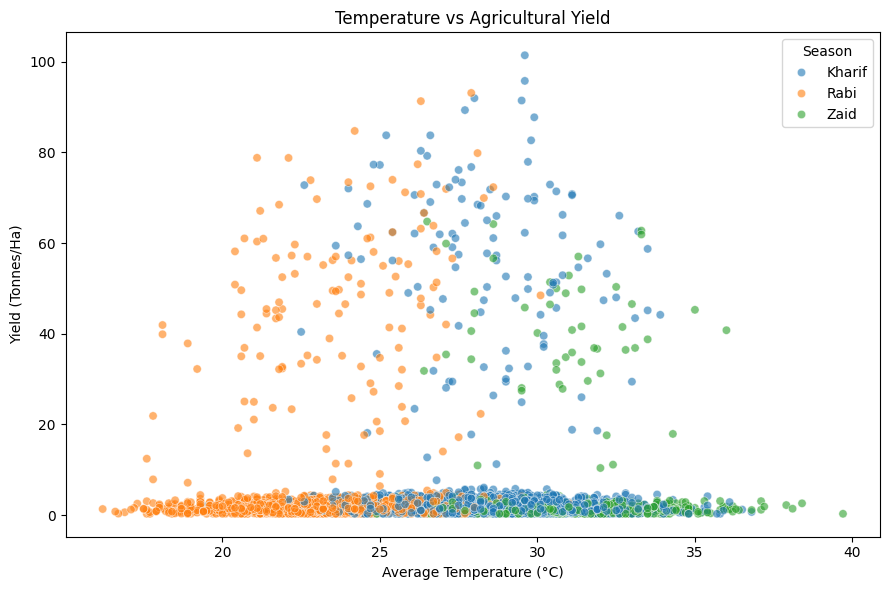

In [95]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha',
    hue='Season',
    alpha=0.6
)

plt.title('Temperature vs Agricultural Yield')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

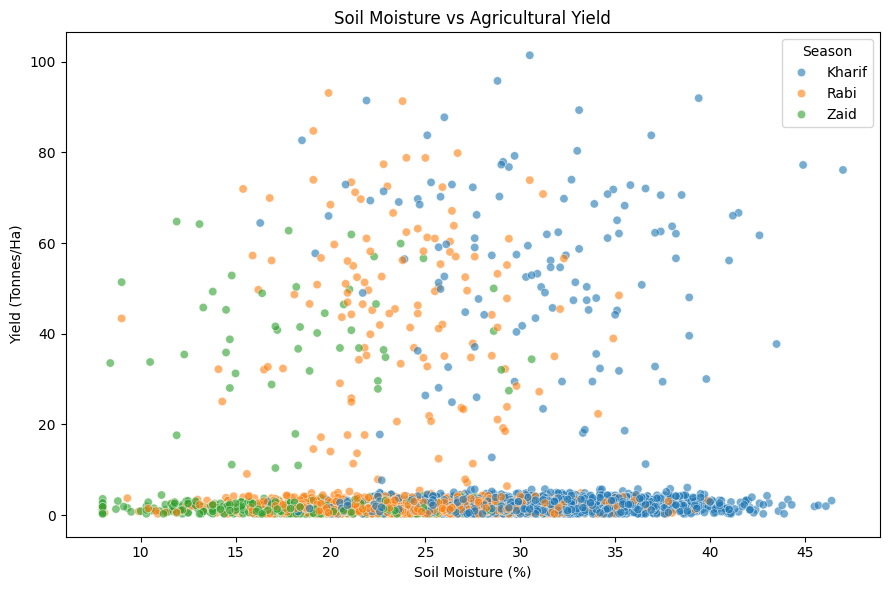

In [96]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x='Soil_Moisture_pct',
    y='Yield_Tonnes_Ha',
    hue='Season',
    alpha=0.6
)

plt.title('Soil Moisture vs Agricultural Yield')
plt.xlabel('Soil Moisture (%)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

In [97]:
profitability_by_season = (
    df_clean
    .groupby('Season')
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Cost=('Total_Cost_INR', 'mean'),
        Avg_Revenue=('Revenue_INR', 'mean'),
        Avg_Profit=('Profit_INR', 'mean'),
        Median_Profit=('Profit_INR', 'median')
    )
    .round(2)
)

profitability_by_season

,Farms,Avg_Cost,Avg_Revenue,Avg_Profit,Median_Profit
Season,,,,,
Kharif,1779,531804.41,710719.06,178914.65,38808.0
Rabi,1627,513836.58,601526.05,87689.47,-3187.0
Zaid,594,543976.73,519171.90,-24804.82,-62144.0


In [98]:
df_clean['Profit_Margin_pct'] = (
    df_clean['Profit_INR'] /
    df_clean['Revenue_INR']
) * 100

profit_margin_by_season = (
    df_clean
    .groupby('Season')['Profit_Margin_pct']
    .agg(['mean', 'median', 'min', 'max'])
    .round(2)
)

profit_margin_by_season

,mean,median,min,max
Season,,,,
Kharif,-38.64,11.09,-1461.85,85.92
Rabi,-44.27,-1.34,-1033.08,82.43
Zaid,-69.35,-24.59,-1040.32,76.65


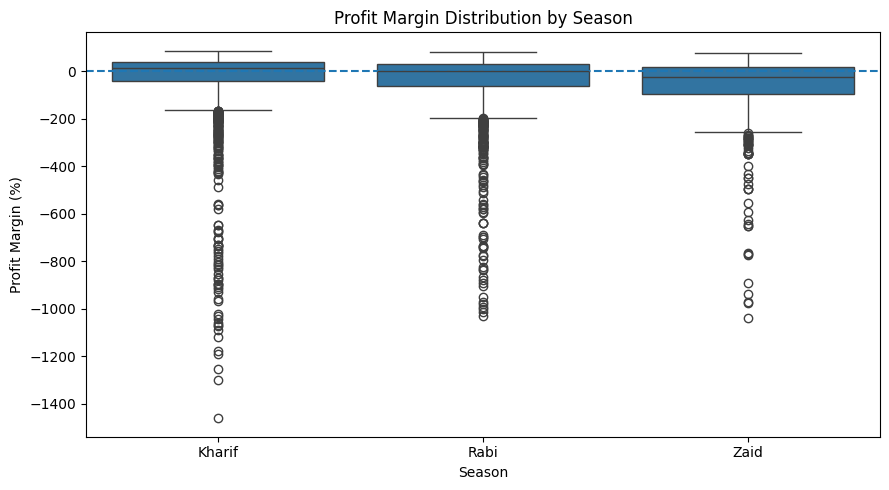

In [99]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x='Season',
    y='Profit_Margin_pct'
)

plt.axhline(
    0,
    linestyle='--'
)

plt.title('Profit Margin Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Profit Margin (%)')

plt.tight_layout()
plt.show()

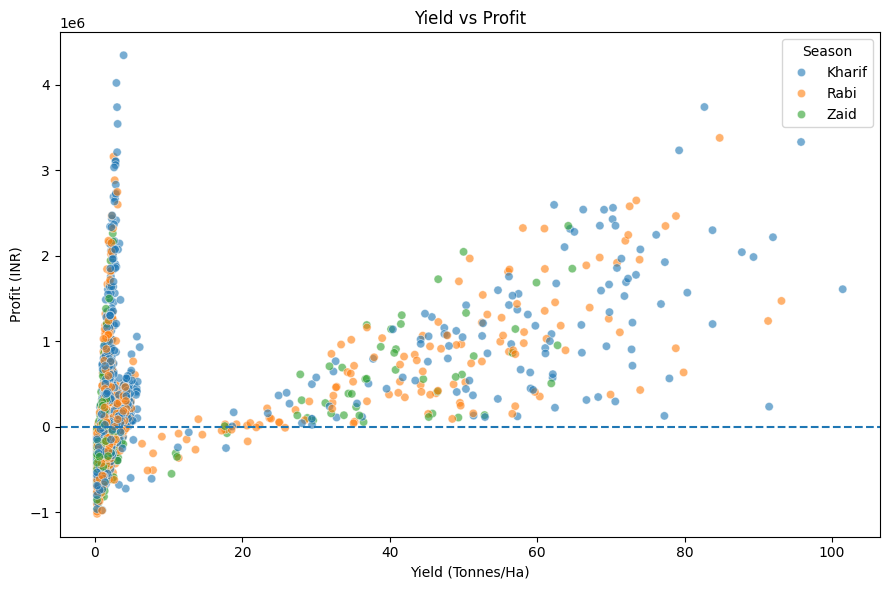

In [100]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x='Yield_Tonnes_Ha',
    y='Profit_INR',
    hue='Season',
    alpha=0.6
)

plt.axhline(
    0,
    linestyle='--'
)

plt.title('Yield vs Profit')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Profit (INR)')

plt.tight_layout()
plt.show()

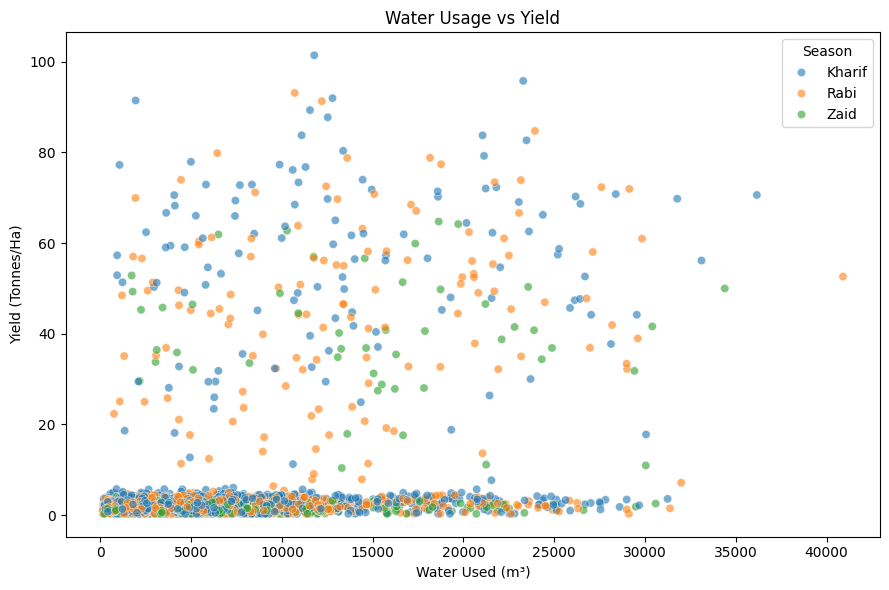

In [101]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x='Water_Used_m3',
    y='Yield_Tonnes_Ha',
    hue='Season',
    alpha=0.6
)

plt.title('Water Usage vs Yield')
plt.xlabel('Water Used (m³)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

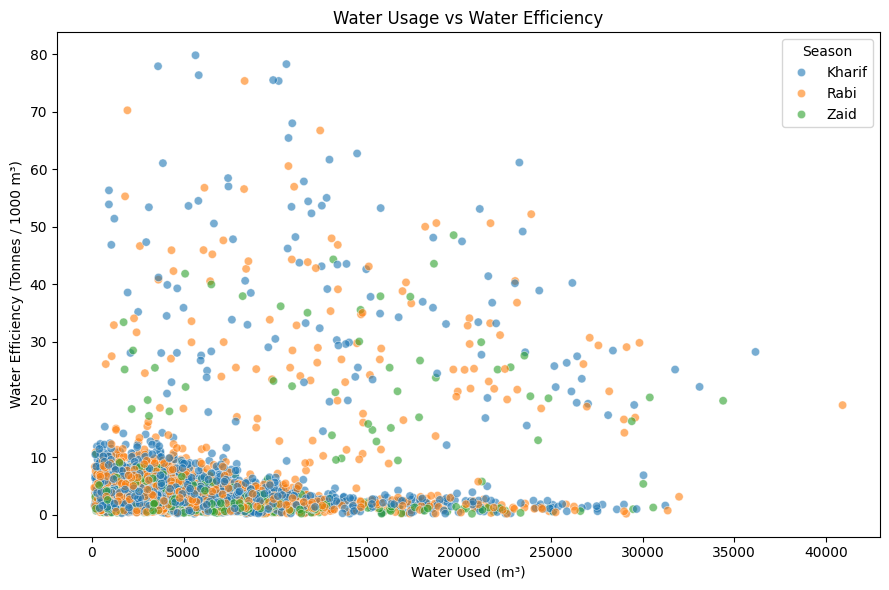

In [102]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x='Water_Used_m3',
    y='Water_Efficiency_t_per_1000m3',
    hue='Season',
    alpha=0.6
)

plt.title('Water Usage vs Water Efficiency')
plt.xlabel('Water Used (m³)')
plt.ylabel('Water Efficiency (Tonnes / 1000 m³)')

plt.tight_layout()
plt.show()

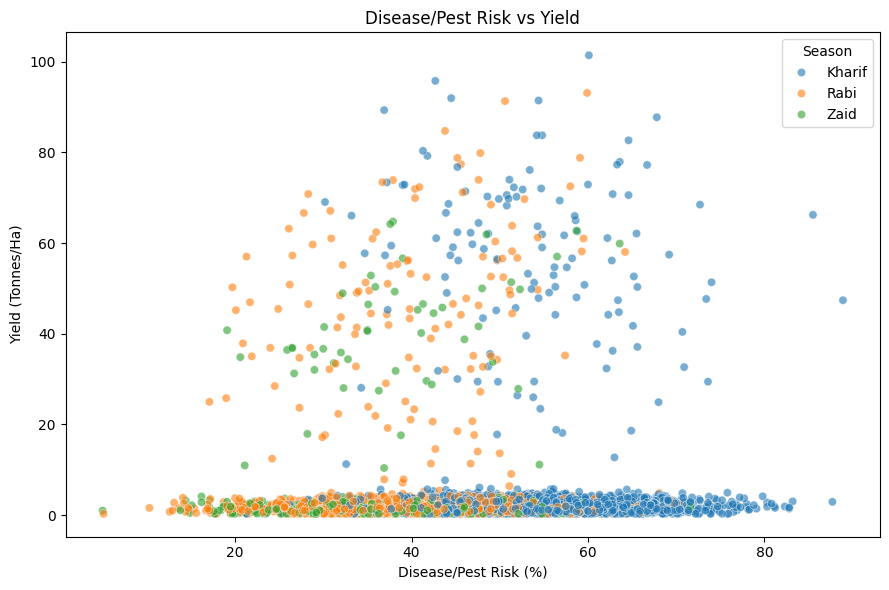

In [103]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x='Disease_Pest_Risk_pct',
    y='Yield_Tonnes_Ha',
    hue='Season',
    alpha=0.6
)

plt.title('Disease/Pest Risk vs Yield')
plt.xlabel('Disease/Pest Risk (%)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

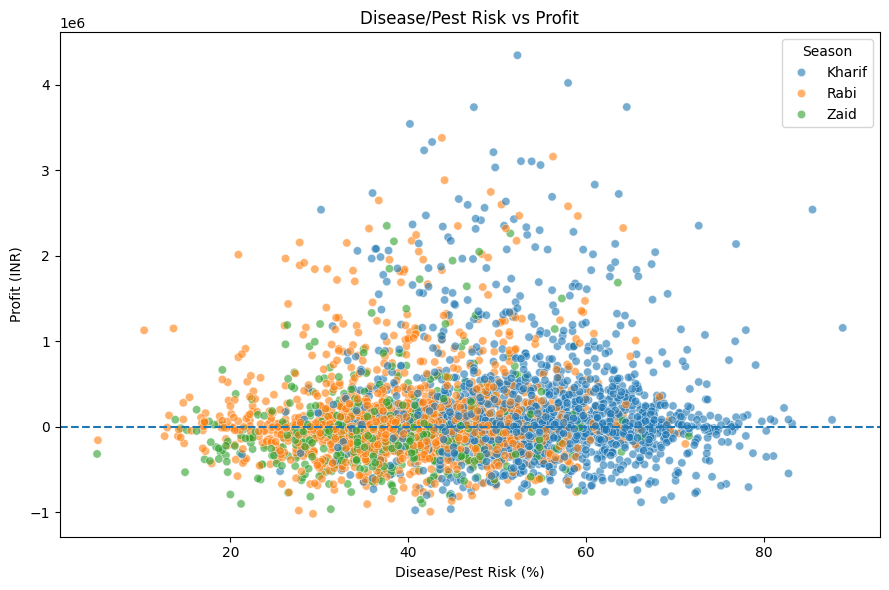

In [104]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x='Disease_Pest_Risk_pct',
    y='Profit_INR',
    hue='Season',
    alpha=0.6
)

plt.axhline(
    0,
    linestyle='--'
)

plt.title('Disease/Pest Risk vs Profit')
plt.xlabel('Disease/Pest Risk (%)')
plt.ylabel('Profit (INR)')

plt.tight_layout()
plt.show()

In [105]:
season_scorecard = df_clean.groupby('Season').agg({

    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Profit_INR': 'mean',
    'Profit_Margin_pct': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'

}).round(2)

season_scorecard

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Profit_Margin_pct,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,
Kharif,5.63,46.31,178914.65,-38.64,6102.20,5.89,54.47
Rabi,5.09,41.49,87689.47,-44.27,5846.99,5.19,40.48
Zaid,4.63,38.89,-24804.82,-69.35,6419.89,4.41,38.22


In [106]:
season_rankings = season_scorecard.copy()

season_rankings['Yield_Rank'] = (
    season_scorecard['Yield_Tonnes_Ha']
    .rank(ascending=False)
)

season_rankings['Profit_Rank'] = (
    season_scorecard['Profit_INR']
    .rank(ascending=False)
)

season_rankings['Water_Efficiency_Rank'] = (
    season_scorecard['Water_Efficiency_t_per_1000m3']
    .rank(ascending=False)
)

season_rankings['Disease_Risk_Rank'] = (
    season_scorecard['Disease_Pest_Risk_pct']
    .rank(ascending=True)
)

season_rankings

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Profit_Margin_pct,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Yield_Rank,Profit_Rank,Water_Efficiency_Rank,Disease_Risk_Rank
Season,,,,,,,,,,,
Kharif,5.63,46.31,178914.65,-38.64,6102.20,5.89,54.47,1.0,1.0,1.0,3.0
Rabi,5.09,41.49,87689.47,-44.27,5846.99,5.19,40.48,2.0,2.0,2.0,2.0
Zaid,4.63,38.89,-24804.82,-69.35,6419.89,4.41,38.22,3.0,3.0,3.0,1.0


In [107]:
df_clean.to_csv(
    'seasonal_agriculture_performance_clean.csv',
    index=False
)

print("Updated clean dataset saved successfully.")

Updated clean dataset saved successfully.


In [108]:
correlation_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

correlation_matrix = (
    df_clean[correlation_columns]
    .corr()
    .round(2)
)

correlation_matrix

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Rainfall_mm,1.00,0.20,0.53,-0.37,0.02,0.52,0.01,0.02,0.03,0.02,0.00,-0.02,0.03,0.02,0.00,0.01,0.10,0.11,0.00,0.06,0.62
Avg_Temperature_C,0.20,1.00,0.14,-0.03,0.03,0.08,0.02,0.01,0.02,0.02,0.01,-0.03,0.01,0.01,0.00,0.04,0.03,0.01,0.02,0.01,0.25
Humidity_pct,0.53,0.14,1.00,-0.30,0.03,0.45,0.00,-0.01,-0.00,0.02,-0.00,-0.05,0.01,0.00,0.00,0.01,0.06,0.06,-0.00,0.03,0.55
Sunlight_Hours_Day,-0.37,-0.03,-0.30,1.00,-0.02,-0.30,0.01,0.00,-0.01,-0.01,-0.02,0.02,-0.02,-0.02,-0.00,-0.00,-0.05,-0.05,-0.01,-0.02,-0.25
Soil_pH,0.02,0.03,0.03,-0.02,1.00,0.03,0.01,0.02,-0.02,-0.01,-0.01,-0.00,-0.02,-0.01,0.02,0.01,-0.01,-0.01,-0.02,-0.01,0.03
Soil_Moisture_pct,0.52,0.08,0.45,-0.30,0.03,1.00,0.01,0.01,0.01,0.01,-0.02,-0.02,0.01,0.01,0.02,0.00,0.08,0.09,0.00,0.03,0.38
Nitrogen_kg_ha,0.01,0.02,0.00,0.01,0.01,0.01,1.00,0.01,0.01,-0.03,0.01,0.01,0.05,0.05,-0.02,0.01,0.08,0.09,0.02,0.05,-0.01
Phosphorus_kg_ha,0.02,0.01,-0.01,0.00,0.02,0.01,0.01,1.00,0.00,0.01,-0.03,-0.01,0.05,0.03,-0.01,-0.02,0.03,0.05,-0.00,0.06,0.03
Potassium_kg_ha,0.03,0.02,-0.00,-0.01,-0.02,0.01,0.01,0.00,1.00,0.02,-0.00,0.01,0.01,0.00,0.01,0.00,0.03,0.03,0.00,0.01,0.01
Fertilizer_kg_ha,0.02,0.02,0.02,-0.01,-0.01,0.01,-0.03,0.01,0.02,1.00,-0.00,0.02,-0.00,0.00,-0.00,0.15,0.01,-0.07,0.00,0.01,0.02


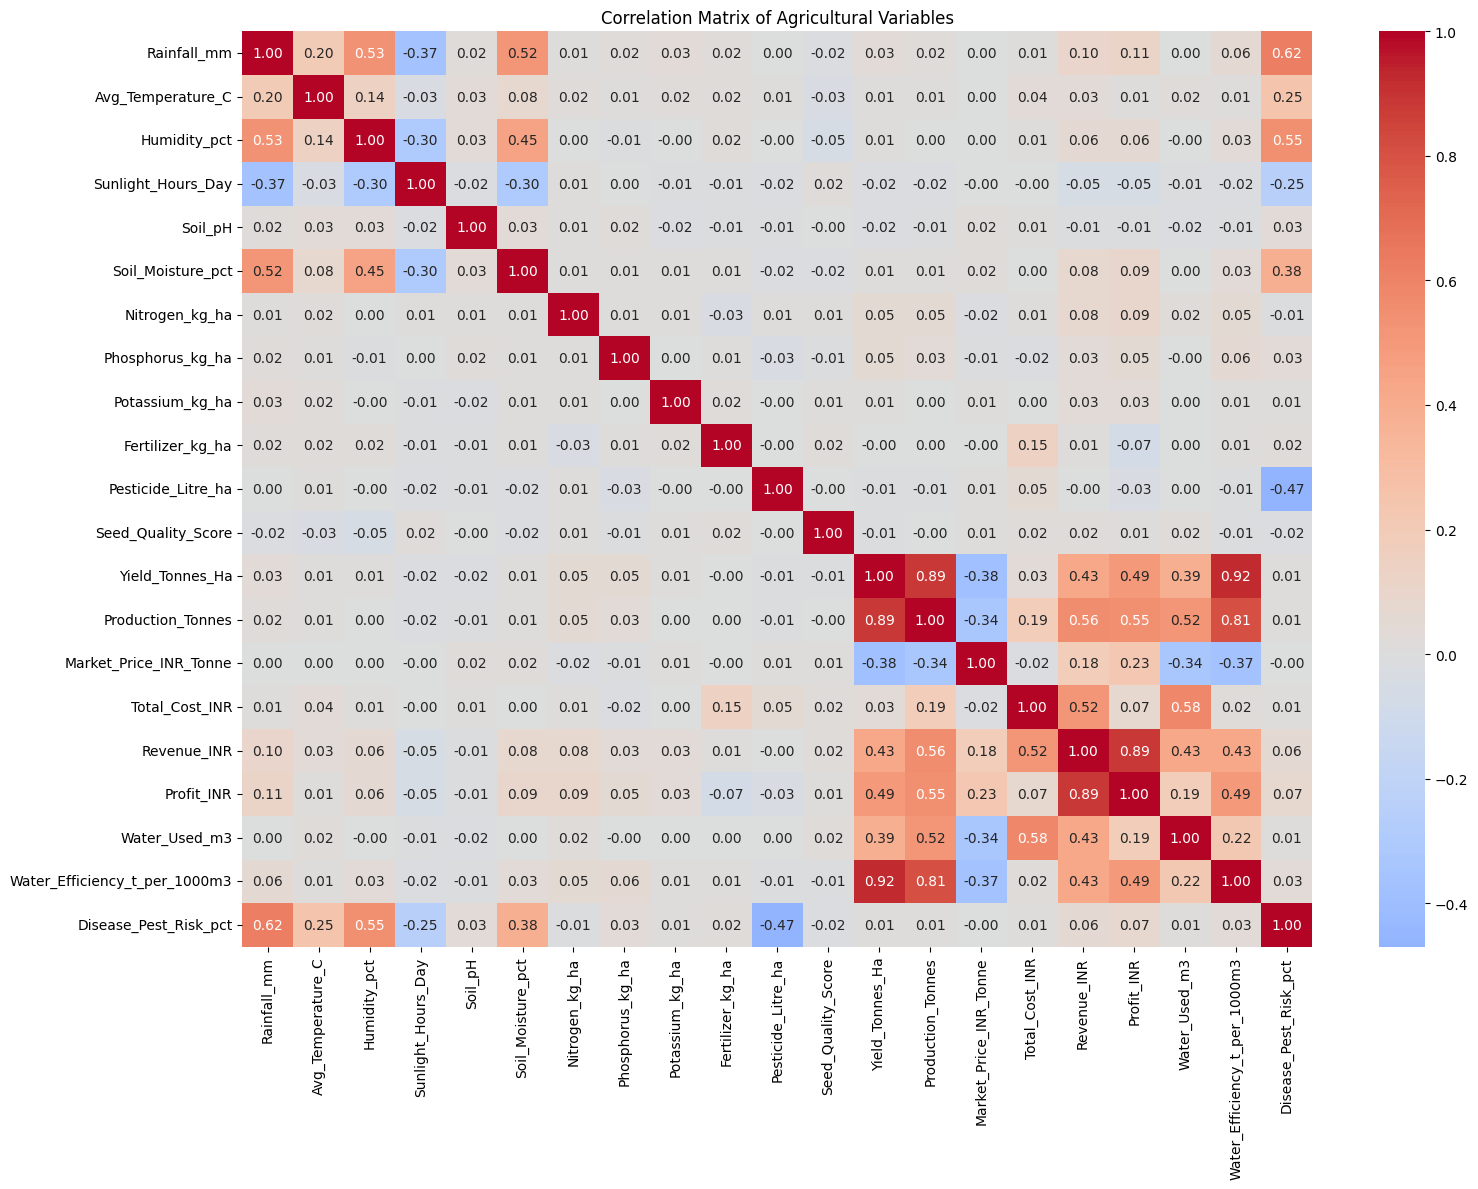

In [109]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Agricultural Variables')

plt.tight_layout()
plt.show()

In [110]:
yield_correlations = (
    correlation_matrix['Yield_Tonnes_Ha']
    .drop('Yield_Tonnes_Ha')
    .sort_values(ascending=False)
)

yield_correlations

,Yield_Tonnes_Ha
Water_Efficiency_t_per_1000m3,0.92
Production_Tonnes,0.89
Profit_INR,0.49
Revenue_INR,0.43
Water_Used_m3,0.39
Phosphorus_kg_ha,0.05
Nitrogen_kg_ha,0.05
Rainfall_mm,0.03
Total_Cost_INR,0.03
Potassium_kg_ha,0.01


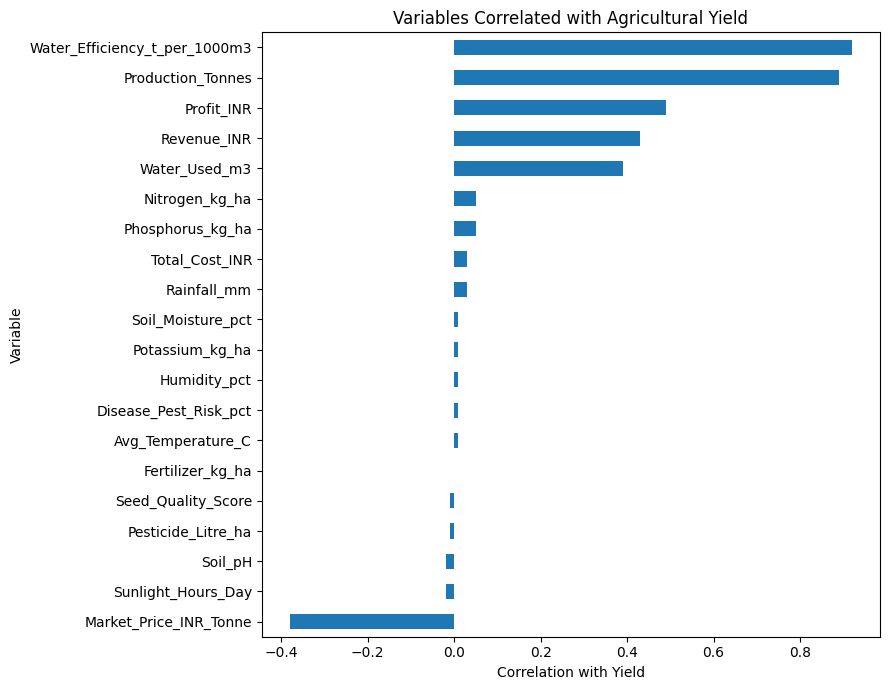

In [111]:
plt.figure(figsize=(9, 7))

yield_correlations.sort_values().plot(
    kind='barh'
)

plt.title('Variables Correlated with Agricultural Yield')
plt.xlabel('Correlation with Yield')
plt.ylabel('Variable')

plt.tight_layout()
plt.show()

In [112]:
profit_correlations = (
    correlation_matrix['Profit_INR']
    .drop('Profit_INR')
    .sort_values(ascending=False)
)

profit_correlations

,Profit_INR
Revenue_INR,0.89
Production_Tonnes,0.55
Water_Efficiency_t_per_1000m3,0.49
Yield_Tonnes_Ha,0.49
Market_Price_INR_Tonne,0.23
Water_Used_m3,0.19
Rainfall_mm,0.11
Soil_Moisture_pct,0.09
Nitrogen_kg_ha,0.09
Total_Cost_INR,0.07


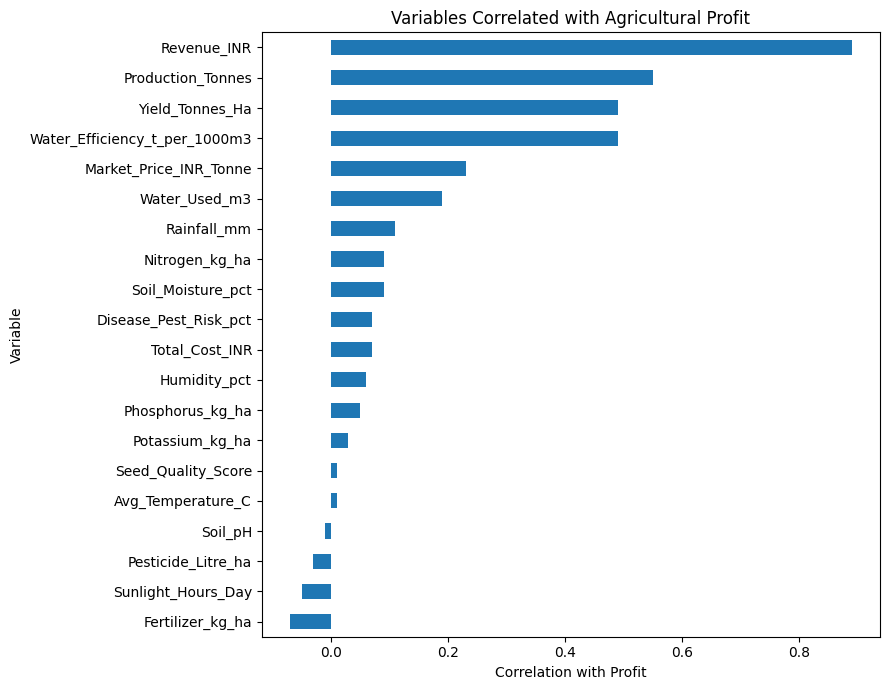

In [113]:
plt.figure(figsize=(9, 7))

profit_correlations.sort_values().plot(
    kind='barh'
)

plt.title('Variables Correlated with Agricultural Profit')
plt.xlabel('Correlation with Profit')
plt.ylabel('Variable')

plt.tight_layout()
plt.show()

In [114]:
season_groups = [
    group['Yield_Tonnes_Ha'].dropna()
    for name, group in df_clean.groupby('Season')
]

anova_yield = stats.f_oneway(*season_groups)

print("F-statistic:", anova_yield.statistic)
print("p-value:", anova_yield.pvalue)

F-statistic: 1.4629465929298864
p-value: 0.2316769350005544


In [115]:
if anova_yield.pvalue < 0.05:
    print("Result: Significant difference in yield across seasons.")
else:
    print("Result: No statistically significant difference in yield across seasons.")

Result: No statistically significant difference in yield across seasons.


In [116]:
profit_groups = [
    group['Profit_INR'].dropna()
    for name, group in df_clean.groupby('Season')
]

anova_profit = stats.f_oneway(*profit_groups)

print("F-statistic:", anova_profit.statistic)
print("p-value:", anova_profit.pvalue)

if anova_profit.pvalue < 0.05:
    print("Result: Significant difference in profit across seasons.")
else:
    print("Result: No statistically significant difference in profit across seasons.")

F-statistic: 34.29175033935195
p-value: 1.7124156677360182e-15
Result: Significant difference in profit across seasons.


In [117]:
water_groups = [
    group['Water_Efficiency_t_per_1000m3'].dropna()
    for name, group in df_clean.groupby('Season')
]

anova_water = stats.f_oneway(*water_groups)

print("F-statistic:", anova_water.statistic)
print("p-value:", anova_water.pvalue)

if anova_water.pvalue < 0.05:
    print("Result: Significant difference in water efficiency across seasons.")
else:
    print("Result: No statistically significant difference in water efficiency across seasons.")

F-statistic: 6.948269603965189
p-value: 0.0009719376945376617
Result: Significant difference in water efficiency across seasons.


In [118]:
season_irrigation_table = pd.crosstab(
    df_clean['Season'],
    df_clean['Irrigation_Method']
)

print("Contingency Table:")
display(season_irrigation_table)

chi2, p_value, dof, expected = stats.chi2_contingency(
    season_irrigation_table
)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

if p_value < 0.05:
    print("Result: Season and irrigation method are statistically associated.")
else:
    print("Result: No statistically significant association between season and irrigation method.")

Contingency Table:


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,405,590,463,321
Rabi,370,526,438,293
Zaid,140,194,140,120


Chi-square statistic: 3.5126697129275857
p-value: 0.7422832892677165
Degrees of freedom: 6
Result: No statistically significant association between season and irrigation method.


In [119]:
statistical_results = pd.DataFrame({
    'Test': [
        'ANOVA — Yield by Season',
        'ANOVA — Profit by Season',
        'ANOVA — Water Efficiency by Season',
        'Chi-square — Season vs Irrigation'
    ],

    'Statistic': [
        anova_yield.statistic,
        anova_profit.statistic,
        anova_water.statistic,
        chi2
    ],

    'P_Value': [
        anova_yield.pvalue,
        anova_profit.pvalue,
        anova_water.pvalue,
        p_value
    ]
})

statistical_results['Significant_at_0.05'] = (
    statistical_results['P_Value'] < 0.05
)

statistical_results.round(4)

,Test,Statistic,P_Value,Significant_at_0.05
0,ANOVA — Yield by Season,1.4629,0.2317,False
1,ANOVA — Profit by Season,34.2918,0.0000,True
2,ANOVA — Water Efficiency by Season,6.9483,0.0010,True
3,Chi-square — Season vs Irrigation,3.5127,0.7423,False


In [120]:
crop_performance = (
    df_clean
    .groupby('Crop')
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Avg_Production=('Production_Tonnes', 'mean'),
        Avg_Cost=('Total_Cost_INR', 'mean'),
        Avg_Revenue=('Revenue_INR', 'mean'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Water_Efficiency=(
            'Water_Efficiency_t_per_1000m3',
            'mean'
        ),
        Avg_Disease_Risk=(
            'Disease_Pest_Risk_pct',
            'mean'
        )
    )
    .round(2)
)

crop_performance

,Farms,Avg_Yield,Avg_Production,Avg_Cost,Avg_Revenue,Avg_Profit,Avg_Water_Efficiency,Avg_Disease_Risk
Crop,,,,,,,,
Chilli,412,1.54,12.38,525898.89,1276777.23,750878.34,2.95,46.06
Cotton,508,1.22,9.40,514876.17,639423.08,124546.92,1.94,45.97
Groundnut,424,1.32,9.66,498077.38,542935.50,44858.12,3.15,46.29
Maize,551,2.71,21.78,541046.32,457067.99,-83978.33,5.60,45.54
Pulses,496,0.92,7.40,532703.92,528465.87,-4238.05,2.90,46.57
Rice,690,2.44,19.29,525828.76,423615.26,-102213.50,1.95,46.50
Sugarcane,305,46.93,392.41,554792.13,1371980.11,817187.99,30.48,45.40
Wheat,614,2.11,16.85,523503.22,400104.89,-123398.34,4.63,47.85


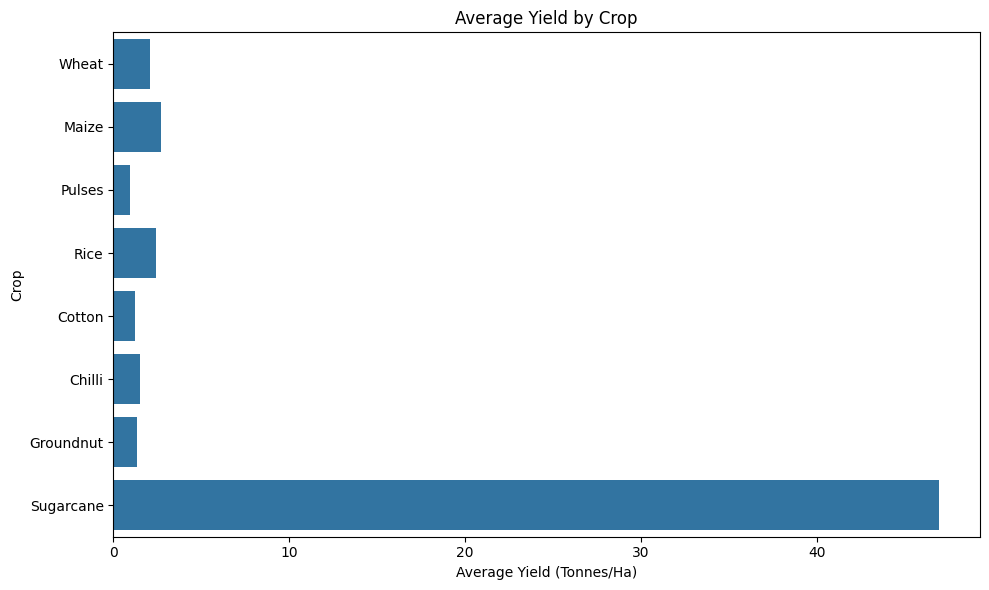

In [121]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_clean,
    y='Crop',
    x='Yield_Tonnes_Ha',
    estimator='mean',
    errorbar=None
)

plt.title('Average Yield by Crop')
plt.xlabel('Average Yield (Tonnes/Ha)')
plt.ylabel('Crop')

plt.tight_layout()
plt.show()

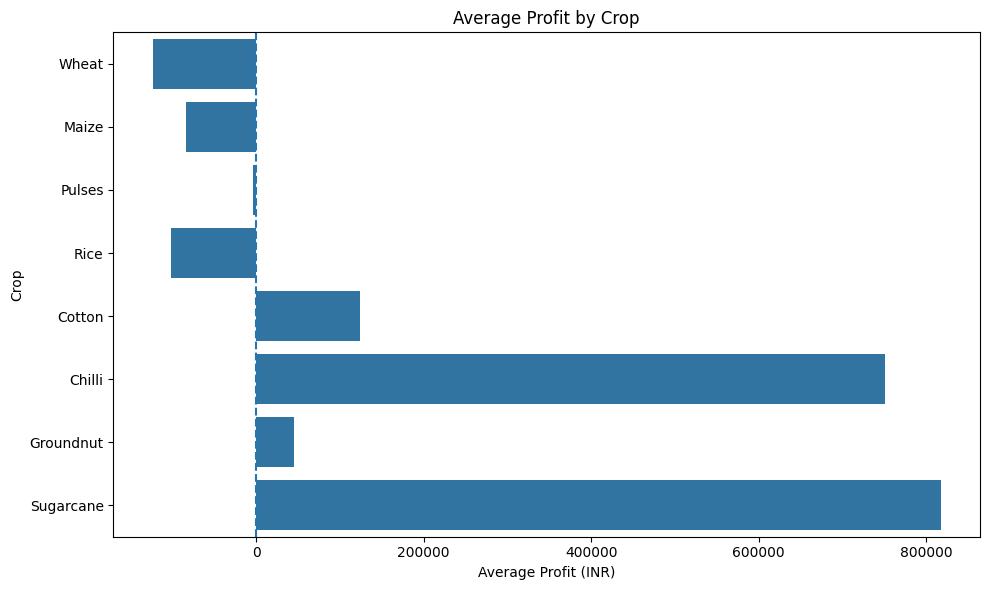

In [122]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_clean,
    y='Crop',
    x='Profit_INR',
    estimator='mean',
    errorbar=None
)

plt.axvline(
    0,
    linestyle='--'
)

plt.title('Average Profit by Crop')
plt.xlabel('Average Profit (INR)')
plt.ylabel('Crop')

plt.tight_layout()
plt.show()

In [123]:
state_performance = (
    df_clean
    .groupby('State')
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Water_Used=('Water_Used_m3', 'mean'),
        Avg_Water_Efficiency=(
            'Water_Efficiency_t_per_1000m3',
            'mean'
        ),
        Avg_Disease_Risk=(
            'Disease_Pest_Risk_pct',
            'mean'
        )
    )
    .sort_values('Avg_Profit', ascending=False)
    .round(2)
)

state_performance

,Farms,Avg_Yield,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Risk
State,,,,,,
Punjab,484,6.12,136025.64,6565.92,5.62,46.00
Maharashtra,512,5.01,135428.86,5968.08,5.28,46.44
Karnataka,489,5.75,119422.34,6414.33,5.56,46.06
Tamil Nadu,485,4.87,117744.75,5775.22,5.31,46.28
Gujarat,488,5.76,117568.24,6142.50,5.58,45.95
Telangana,516,5.05,108829.62,5801.83,5.46,46.36
Madhya Pradesh,497,4.98,86840.76,5663.92,5.27,47.08
Andhra Pradesh,529,4.63,73453.53,6058.38,5.03,46.72


In [124]:
state_performance.sort_values(
    'Avg_Yield',
    ascending=False
).head(10)

,Farms,Avg_Yield,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Risk
State,,,,,,
Punjab,484,6.12,136025.64,6565.92,5.62,46.00
Gujarat,488,5.76,117568.24,6142.50,5.58,45.95
Karnataka,489,5.75,119422.34,6414.33,5.56,46.06
Telangana,516,5.05,108829.62,5801.83,5.46,46.36
Maharashtra,512,5.01,135428.86,5968.08,5.28,46.44
Madhya Pradesh,497,4.98,86840.76,5663.92,5.27,47.08
Tamil Nadu,485,4.87,117744.75,5775.22,5.31,46.28
Andhra Pradesh,529,4.63,73453.53,6058.38,5.03,46.72


In [125]:
state_performance.sort_values(
    'Avg_Profit',
    ascending=False
).head(10)

,Farms,Avg_Yield,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Risk
State,,,,,,
Punjab,484,6.12,136025.64,6565.92,5.62,46.00
Maharashtra,512,5.01,135428.86,5968.08,5.28,46.44
Karnataka,489,5.75,119422.34,6414.33,5.56,46.06
Tamil Nadu,485,4.87,117744.75,5775.22,5.31,46.28
Gujarat,488,5.76,117568.24,6142.50,5.58,45.95
Telangana,516,5.05,108829.62,5801.83,5.46,46.36
Madhya Pradesh,497,4.98,86840.76,5663.92,5.27,47.08
Andhra Pradesh,529,4.63,73453.53,6058.38,5.03,46.72


In [126]:
district_performance = (
    df_clean
    .groupby(['State', 'District'])
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Water_Efficiency=(
            'Water_Efficiency_t_per_1000m3',
            'mean'
        )
    )
    .round(2)
)

print("Top 10 Districts by Yield:")
display(
    district_performance
    .sort_values('Avg_Yield', ascending=False)
    .head(10)
)

print("Top 10 Districts by Profit:")
display(
    district_performance
    .sort_values('Avg_Profit', ascending=False)
    .head(10)
)

Top 10 Districts by Yield:


,,Farms,Avg_Yield,Avg_Profit,Avg_Water_Efficiency
State,District,,,,
Karnataka,Nalgonda,52,11.85,167340.94,9.16
Gujarat,Indore,34,9.85,42073.32,6.79
Karnataka,Rajkot,58,9.40,100128.17,7.41
Punjab,Warangal,57,8.98,301710.33,7.48
Madhya Pradesh,Warangal,62,8.29,213645.69,6.73
Gujarat,Rajkot,48,8.13,230545.21,7.37
Telangana,Raichur,35,7.87,186997.34,7.28
Punjab,Ludhiana,48,7.78,62368.90,6.65
Madhya Pradesh,Ludhiana,57,7.49,78735.12,7.12


Top 10 Districts by Profit:


,,Farms,Avg_Yield,Avg_Profit,Avg_Water_Efficiency
State,District,,,,
Maharashtra,Ludhiana,46,6.44,343630.28,6.32
Punjab,Warangal,57,8.98,301710.33,7.48
Gujarat,Warangal,53,5.44,296406.26,5.97
Tamil Nadu,Guntur,52,7.12,273192.90,7.53
Gujarat,Rajkot,48,8.13,230545.21,7.37
Tamil Nadu,Erode,51,4.86,229582.84,4.87
Karnataka,Indore,42,5.17,215980.05,5.17
Madhya Pradesh,Warangal,62,8.29,213645.69,6.73
Punjab,Raichur,43,2.78,207547.21,4.28


In [127]:
irrigation_performance = (
    df_clean
    .groupby('Irrigation_Method')
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Water_Used=('Water_Used_m3', 'mean'),
        Avg_Water_Efficiency=(
            'Water_Efficiency_t_per_1000m3',
            'mean'
        )
    )
    .round(2)
)

irrigation_performance

,Farms,Avg_Yield,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency
Irrigation_Method,,,,,
Drip,915,6.68,219626.00,5918.75,6.27
Flood,1310,4.86,73354.02,8026.47,3.44
Rainfed,1041,4.60,79050.37,3549.55,7.56
Sprinkler,734,5.16,91121.08,6208.26,4.67


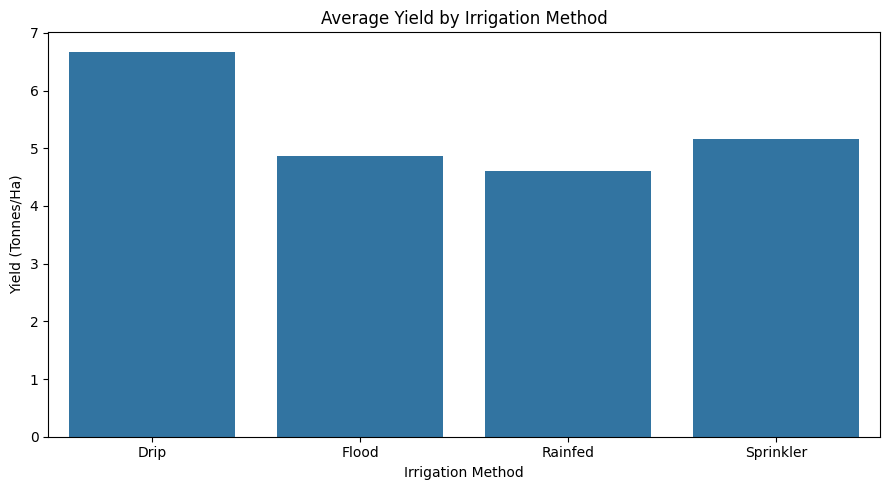

In [128]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df_clean,
    x='Irrigation_Method',
    y='Yield_Tonnes_Ha',
    estimator='mean',
    errorbar=None
)

plt.title('Average Yield by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

In [129]:
crop_season_performance = (
    df_clean
    .groupby(['Crop', 'Season'])
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Water_Efficiency=(
            'Water_Efficiency_t_per_1000m3',
            'mean'
        ),
        Avg_Disease_Risk=(
            'Disease_Pest_Risk_pct',
            'mean'
        )
    )
    .round(2)
)

crop_season_performance

Farms  Avg_Yield  Avg_Profit  Avg_Water_Efficiency  \
Crop      Season                                                       
Chilli    Kharif    185       1.73   954380.42                  3.26   
          Rabi      163       1.46   638572.50                  2.89   
          Zaid       64       1.18   448659.09                  2.20   
Cotton    Kharif    215       1.37   216999.55                  2.13   
          Rabi      201       1.19   107343.59                  1.94   
          Zaid       92       0.94   -53925.34                  1.49   
Groundnut Kharif    193       1.48   108265.44                  3.58   
          Rabi      177       1.23    10416.54                  2.90   
          Zaid       54       1.04   -68872.50                  2.47   
Maize     Kharif    234       2.97   -39332.67                  6.05   
          Rabi      233       2.62   -89133.40                  5.46   
          Zaid       84       2.28  -194049.17                  4.75   
Pulses    Kharif    221       1.04    43338.90                  3.35   
          Rabi      213       0.87   -14309.14                  2.70   
          Zaid       62       0.65  -139227.81                  1.95   
Rice      Kharif    314       2.71   -64903.40                  2.17   
          Rabi      274       2.33   -98427.87                  1.84   
          Zaid      102       1.90  -227239.34                  1.53   
Sugarcane Kharif    125      53.46  1000790.81                 36.00   
          Rabi      129      43.95   731612.86                 27.92   
          Zaid       51      38.42   583635.80                 23.39   
Wheat     Kharif    292       2.25  -105871.87                  4.76   
          Rabi      237       2.06  -119954.57                  4.69   
          Zaid       85       1.75  -193208.95                  4.02   

                  Avg_Disease_Risk  
Crop      Season                    
Chilli    Kharif             52.81  
          Rabi               40.59  
          Zaid               40.50  
Cotton    Kharif             54.24  
          Rabi               41.54  
          Zaid               36.34  
Groundnut Kharif             54.28  
          Rabi               39.76  
          Zaid               39.13  
Maize     Kharif             54.82  
          Rabi               39.41  
          Zaid               36.68  
Pulses    Kharif             54.96  
          Rabi               40.08  
          Zaid               38.97  
Rice      Kharif             54.25  
          Rabi               40.79  
          Zaid               37.95  
Sugarcane Kharif             54.02  
          Rabi               39.85  
          Zaid               38.35  
Wheat     Kharif             55.58  
          Rabi               41.46  
          Zaid               39.16

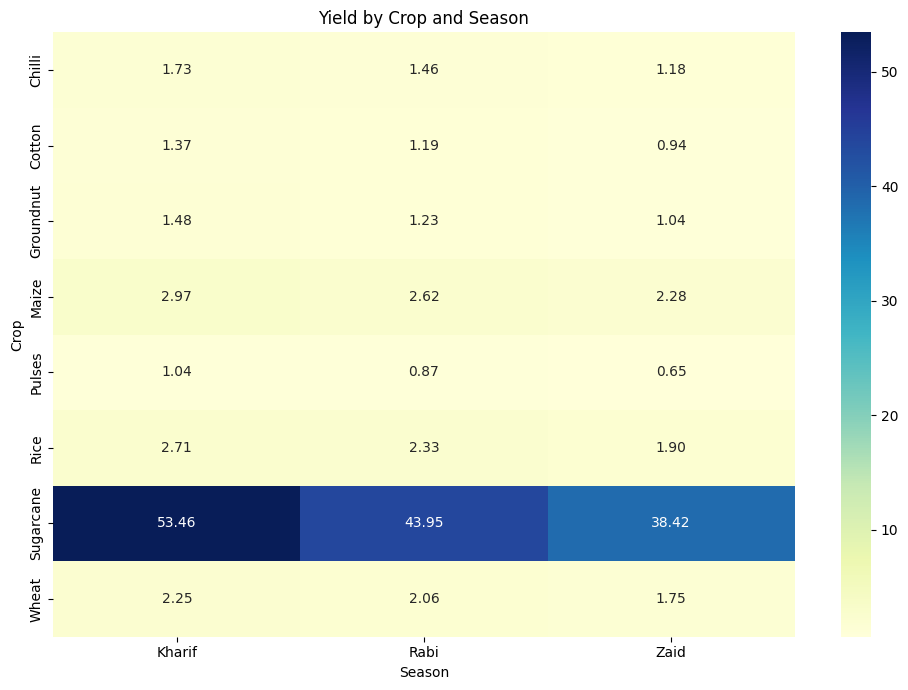

In [130]:
yield_crop_season = df_clean.pivot_table(
    index='Crop',
    columns='Season',
    values='Yield_Tonnes_Ha',
    aggfunc='mean'
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    yield_crop_season,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Yield by Crop and Season')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.tight_layout()
plt.show()

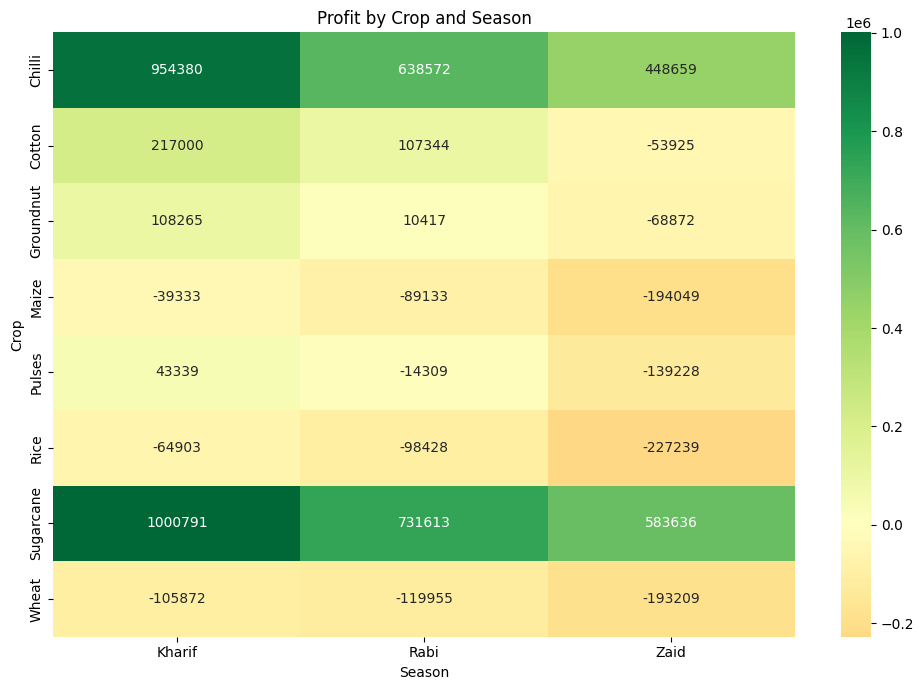

In [131]:
profit_crop_season = df_clean.pivot_table(
    index='Crop',
    columns='Season',
    values='Profit_INR',
    aggfunc='mean'
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    profit_crop_season,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    center=0
)

plt.title('Profit by Crop and Season')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.tight_layout()
plt.show()

In [132]:
crop_groups = [
    group['Yield_Tonnes_Ha'].dropna()
    for name, group in df_clean.groupby('Crop')
]

anova_crop = stats.f_oneway(*crop_groups)

print("F-statistic:", anova_crop.statistic)
print("p-value:", anova_crop.pvalue)

if anova_crop.pvalue < 0.05:
    print("Result: Yield differs significantly between at least some crops.")
else:
    print("Result: No statistically significant difference in yield between crops.")

F-statistic: 2384.4937749067863
p-value: 0.0
Result: Yield differs significantly between at least some crops.


In [133]:
print("=" * 70)
print("CROP PERFORMANCE")
print("=" * 70)

display(crop_performance)

print("=" * 70)
print("STATE PERFORMANCE")
print("=" * 70)

display(state_performance)

print("=" * 70)
print("IRRIGATION PERFORMANCE")
print("=" * 70)

display(irrigation_performance)

CROP PERFORMANCE


,Farms,Avg_Yield,Avg_Production,Avg_Cost,Avg_Revenue,Avg_Profit,Avg_Water_Efficiency,Avg_Disease_Risk
Crop,,,,,,,,
Chilli,412,1.54,12.38,525898.89,1276777.23,750878.34,2.95,46.06
Cotton,508,1.22,9.40,514876.17,639423.08,124546.92,1.94,45.97
Groundnut,424,1.32,9.66,498077.38,542935.50,44858.12,3.15,46.29
Maize,551,2.71,21.78,541046.32,457067.99,-83978.33,5.60,45.54
Pulses,496,0.92,7.40,532703.92,528465.87,-4238.05,2.90,46.57
Rice,690,2.44,19.29,525828.76,423615.26,-102213.50,1.95,46.50
Sugarcane,305,46.93,392.41,554792.13,1371980.11,817187.99,30.48,45.40
Wheat,614,2.11,16.85,523503.22,400104.89,-123398.34,4.63,47.85


STATE PERFORMANCE


,Farms,Avg_Yield,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Risk
State,,,,,,
Punjab,484,6.12,136025.64,6565.92,5.62,46.00
Maharashtra,512,5.01,135428.86,5968.08,5.28,46.44
Karnataka,489,5.75,119422.34,6414.33,5.56,46.06
Tamil Nadu,485,4.87,117744.75,5775.22,5.31,46.28
Gujarat,488,5.76,117568.24,6142.50,5.58,45.95
Telangana,516,5.05,108829.62,5801.83,5.46,46.36
Madhya Pradesh,497,4.98,86840.76,5663.92,5.27,47.08
Andhra Pradesh,529,4.63,73453.53,6058.38,5.03,46.72


IRRIGATION PERFORMANCE


,Farms,Avg_Yield,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency
Irrigation_Method,,,,,
Drip,915,6.68,219626.00,5918.75,6.27
Flood,1310,4.86,73354.02,8026.47,3.44
Rainfed,1041,4.60,79050.37,3549.55,7.56
Sprinkler,734,5.16,91121.08,6208.26,4.67


In [134]:
yield_median = df_clean['Yield_Tonnes_Ha'].median()
profit_median = df_clean['Profit_INR'].median()

high_yield_low_profit = df_clean[
    (df_clean['Yield_Tonnes_Ha'] > yield_median) &
    (df_clean['Profit_INR'] < profit_median)
].copy()

print(
    "High-yield but low-profit farms:",
    len(high_yield_low_profit)
)

display(
    high_yield_low_profit[
        [
            'Farm_ID',
            'State',
            'District',
            'Crop',
            'Season',
            'Yield_Tonnes_Ha',
            'Total_Cost_INR',
            'Revenue_INR',
            'Profit_INR'
        ]
    ]
    .sort_values('Profit_INR')
    .head(20)
)

High-yield but low-profit farms: 781


,Farm_ID,State,District,Crop,Season,Yield_Tonnes_Ha,Total_Cost_INR,Revenue_INR,Profit_INR
156,SF10157,Punjab,Ludhiana,Sugarcane,Kharif,4.19,907734,182891,-724843
1296,SF11297,Karnataka,Indore,Sugarcane,Kharif,3.27,785319,105119,-680200
3457,SF13458,Tamil Nadu,Indore,Sugarcane,Rabi,2.63,706465,84416,-622049
1556,SF11557,Madhya Pradesh,Warangal,Rice,Rabi,1.92,1035543,415958,-619585
907,SF10908,Tamil Nadu,Raichur,Maize,Zaid,2.35,1258745,640870,-617875
2979,SF12980,Gujarat,Guntur,Sugarcane,Kharif,7.70,950124,340886,-609238
2193,SF12194,Punjab,Nalgonda,Sugarcane,Kharif,4.86,767188,167371,-599817
1352,SF11353,Andhra Pradesh,Ludhiana,Rice,Zaid,2.55,1178677,587911,-590766
338,SF10339,Punjab,Indore,Wheat,Kharif,1.95,1105642,524842,-580800
2051,SF12052,Maharashtra,Warangal,Wheat,Kharif,1.86,1108873,533725,-575148


In [135]:
low_yield_high_profit = df_clean[
    (df_clean['Yield_Tonnes_Ha'] < yield_median) &
    (df_clean['Profit_INR'] > profit_median)
].copy()

print(
    "Low-yield but high-profit farms:",
    len(low_yield_high_profit)
)

display(
    low_yield_high_profit[
        [
            'Farm_ID',
            'State',
            'District',
            'Crop',
            'Season',
            'Yield_Tonnes_Ha',
            'Market_Price_INR_Tonne',
            'Total_Cost_INR',
            'Profit_INR'
        ]
    ]
    .sort_values('Profit_INR', ascending=False)
    .head(20)
)

Low-yield but high-profit farms: 788


,Farm_ID,State,District,Crop,Season,Yield_Tonnes_Ha,Market_Price_INR_Tonne,Total_Cost_INR,Profit_INR
1310,SF11311,Punjab,Rajkot,Chilli,Rabi,1.650000,112879,586190,1842966
1091,SF11092,Punjab,Ludhiana,Chilli,Rabi,1.700000,120569,856215,1667294
1443,SF11444,Tamil Nadu,Indore,Chilli,Kharif,1.480000,106535,783074,1486122
3466,SF13467,Andhra Pradesh,Krishna,Chilli,Zaid,1.510105,113614,1082087,1379928
1274,SF11275,Punjab,Rajkot,Chilli,Kharif,1.660000,108309,717297,1344906
209,SF10210,Maharashtra,Rajkot,Chilli,Rabi,1.420000,111232,981067,1320323
3145,SF13146,Andhra Pradesh,Guntur,Chilli,Kharif,1.550000,103525,894834,1281262
1110,SF11111,Madhya Pradesh,Indore,Chilli,Rabi,1.690000,115031,542991,1276799
1593,SF11594,Andhra Pradesh,Krishna,Pulses,Rabi,1.600000,91070,853156,1203205
3400,SF13401,Gujarat,Warangal,Chilli,Zaid,1.620000,98294,670282,1202219


In [136]:
water_usage_median = df_clean['Water_Used_m3'].median()
water_efficiency_median = (
    df_clean['Water_Efficiency_t_per_1000m3'].median()
)

high_water_low_efficiency = df_clean[
    (df_clean['Water_Used_m3'] > water_usage_median) &
    (
        df_clean['Water_Efficiency_t_per_1000m3']
        < water_efficiency_median
    )
].copy()

print(
    "High-water, low-efficiency farms:",
    len(high_water_low_efficiency)
)

display(
    high_water_low_efficiency[
        [
            'Farm_ID',
            'State',
            'District',
            'Crop',
            'Season',
            'Irrigation_Method',
            'Water_Used_m3',
            'Water_Efficiency_t_per_1000m3',
            'Yield_Tonnes_Ha'
        ]
    ]
    .sort_values('Water_Used_m3', ascending=False)
    .head(20)
)

High-water, low-efficiency farms: 1138


,Farm_ID,State,District,Crop,Season,Irrigation_Method,Water_Used_m3,Water_Efficiency_t_per_1000m3,Yield_Tonnes_Ha
3293,SF13294,Telangana,Indore,Rice,Rabi,Flood,31373,0.700,1.490000
214,SF10215,Punjab,Krishna,Rice,Kharif,Flood,31242,1.567,3.590000
1352,SF11353,Andhra Pradesh,Ludhiana,Rice,Zaid,Flood,30583,1.226,2.550000
3353,SF13354,Tamil Nadu,Erode,Rice,Kharif,Flood,29678,0.967,2.180000
1250,SF11251,Tamil Nadu,Ludhiana,Rice,Zaid,Flood,29489,0.940,1.860000
2829,SF12830,Maharashtra,Guntur,Rice,Rabi,Flood,29111,0.146,0.300000
3864,SF13865,Tamil Nadu,Guntur,Rice,Rabi,Flood,28996,0.570,1.230000
3087,SF13088,Madhya Pradesh,Raichur,Rice,Kharif,Flood,28990,1.749,3.440299
1220,SF11221,Maharashtra,Rajkot,Rice,Kharif,Flood,28602,0.906,1.810000
611,SF10612,Andhra Pradesh,Erode,Rice,Kharif,Flood,27819,1.732,3.390000


In [137]:
risk_threshold = df_clean['Disease_Pest_Risk_pct'].quantile(0.90)

high_risk_farms = df_clean[
    df_clean['Disease_Pest_Risk_pct'] >= risk_threshold
].copy()

print(
    "90th percentile disease/pest risk:",
    round(risk_threshold, 2)
)

print(
    "High-risk farms:",
    len(high_risk_farms)
)

display(
    high_risk_farms[
        [
            'Farm_ID',
            'State',
            'District',
            'Crop',
            'Season',
            'Disease_Pest_Risk_pct',
            'Yield_Tonnes_Ha',
            'Profit_INR'
        ]
    ]
    .sort_values(
        'Disease_Pest_Risk_pct',
        ascending=False
    )
    .head(20)
)

90th percentile disease/pest risk: 62.8
High-risk farms: 402


,Farm_ID,State,District,Crop,Season,Disease_Pest_Risk_pct,Yield_Tonnes_Ha,Profit_INR
1056,SF11057,Telangana,Raichur,Sugarcane,Kharif,88.9,47.40,1156028
2463,SF12464,Tamil Nadu,Ludhiana,Rice,Kharif,87.7,2.93,79818
1194,SF11195,Madhya Pradesh,Warangal,Sugarcane,Kharif,85.5,66.24,2539590
436,SF10437,Andhra Pradesh,Rajkot,Wheat,Kharif,83.2,3.04,37627
3351,SF13352,Madhya Pradesh,Erode,Groundnut,Kharif,82.8,1.46,82839
3534,SF13535,Punjab,Nashik,Wheat,Kharif,82.8,1.70,-547427
2296,SF12297,Tamil Nadu,Nashik,Cotton,Kharif,82.3,1.90,219296
946,SF10947,Karnataka,Nalgonda,Cotton,Kharif,81.2,1.61,64950
407,SF10408,Tamil Nadu,Raichur,Wheat,Kharif,81.1,1.96,-343422
2882,SF12883,Madhya Pradesh,Indore,Wheat,Kharif,80.8,2.56,86780


In [138]:
risk_cutoff = df_clean[
    'Disease_Pest_Risk_pct'
].quantile(0.90)

df_clean['Risk_Group'] = np.where(
    df_clean['Disease_Pest_Risk_pct'] >= risk_cutoff,
    'High Risk',
    'Normal Risk'
)

risk_comparison = (
    df_clean
    .groupby('Risk_Group')
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Water_Efficiency=(
            'Water_Efficiency_t_per_1000m3',
            'mean'
        )
    )
    .round(2)
)

risk_comparison

,Farms,Avg_Yield,Avg_Profit,Avg_Water_Efficiency
Risk_Group,,,,
High Risk,402,5.59,121261.16,5.73
Normal Risk,3598,5.23,110472.17,5.35


In [139]:
crop_season_summary = (
    df_clean
    .groupby(['Crop', 'Season'])
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Water_Efficiency=(
            'Water_Efficiency_t_per_1000m3',
            'mean'
        )
    )
    .round(2)
)

print("TOP CROP-SEASON COMBINATIONS BY YIELD")

display(
    crop_season_summary
    .sort_values('Avg_Yield', ascending=False)
    .head(10)
)

print("BOTTOM CROP-SEASON COMBINATIONS BY YIELD")

display(
    crop_season_summary
    .sort_values('Avg_Yield')
    .head(10)
)

print("TOP CROP-SEASON COMBINATIONS BY PROFIT")

display(
    crop_season_summary
    .sort_values('Avg_Profit', ascending=False)
    .head(10)
)

TOP CROP-SEASON COMBINATIONS BY YIELD


Farms  Avg_Yield  Avg_Profit  Avg_Water_Efficiency
Crop      Season                                                    
Sugarcane Kharif    125      53.46  1000790.81                 36.00
          Rabi      129      43.95   731612.86                 27.92
          Zaid       51      38.42   583635.80                 23.39
Maize     Kharif    234       2.97   -39332.67                  6.05
Rice      Kharif    314       2.71   -64903.40                  2.17
Maize     Rabi      233       2.62   -89133.40                  5.46
Rice      Rabi      274       2.33   -98427.87                  1.84
Maize     Zaid       84       2.28  -194049.17                  4.75
Wheat     Kharif    292       2.25  -105871.87                  4.76
          Rabi      237       2.06  -119954.57                  4.69

BOTTOM CROP-SEASON COMBINATIONS BY YIELD


Farms  Avg_Yield  Avg_Profit  Avg_Water_Efficiency
Crop      Season                                                    
Pulses    Zaid       62       0.65  -139227.81                  1.95
          Rabi      213       0.87   -14309.14                  2.70
Cotton    Zaid       92       0.94   -53925.34                  1.49
Groundnut Zaid       54       1.04   -68872.50                  2.47
Pulses    Kharif    221       1.04    43338.90                  3.35
Chilli    Zaid       64       1.18   448659.09                  2.20
Cotton    Rabi      201       1.19   107343.59                  1.94
Groundnut Rabi      177       1.23    10416.54                  2.90
Cotton    Kharif    215       1.37   216999.55                  2.13
Chilli    Rabi      163       1.46   638572.50                  2.89

TOP CROP-SEASON COMBINATIONS BY PROFIT


,,Farms,Avg_Yield,Avg_Profit,Avg_Water_Efficiency
Crop,Season,,,,
Sugarcane,Kharif,125,53.46,1000790.81,36.00
Chilli,Kharif,185,1.73,954380.42,3.26
Sugarcane,Rabi,129,43.95,731612.86,27.92
Chilli,Rabi,163,1.46,638572.50,2.89
Sugarcane,Zaid,51,38.42,583635.80,23.39
Chilli,Zaid,64,1.18,448659.09,2.20
Cotton,Kharif,215,1.37,216999.55,2.13
Groundnut,Kharif,193,1.48,108265.44,3.58
Cotton,Rabi,201,1.19,107343.59,1.94


In [140]:
season_index = df_clean.groupby('Season').agg({

    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'

})

# Normalize relative to the overall mean

overall_means = df_clean[
    [
        'Yield_Tonnes_Ha',
        'Profit_INR',
        'Water_Efficiency_t_per_1000m3',
        'Disease_Pest_Risk_pct'
    ]
].mean()

season_index_pct = (
    season_index / overall_means * 100
).round(2)

season_index_pct

,Yield_Tonnes_Ha,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,
Kharif,106.95,160.38,109.41,117.47
Rabi,96.77,78.61,96.30,87.31
Zaid,88.03,-22.24,81.95,82.42


In [141]:
season_metrics = df_clean.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean',
    'Profit_Margin_pct': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
})

print("Highest Yield:")
print(
    season_metrics['Yield_Tonnes_Ha']
    .idxmax()
)

print("\nHighest Profit:")
print(
    season_metrics['Profit_INR']
    .idxmax()
)

print("\nHighest Profit Margin:")
print(
    season_metrics['Profit_Margin_pct']
    .idxmax()
)

print("\nHighest Water Efficiency:")
print(
    season_metrics['Water_Efficiency_t_per_1000m3']
    .idxmax()
)

print("\nLowest Disease/Pest Risk:")
print(
    season_metrics['Disease_Pest_Risk_pct']
    .idxmin()
)

Highest Yield:
Kharif

Highest Profit:
Kharif

Highest Profit Margin:
Kharif

Highest Water Efficiency:
Kharif

Lowest Disease/Pest Risk:
Zaid


In [142]:
key_findings = pd.DataFrame({
    'Metric': [
        'Highest Average Yield',
        'Highest Average Profit',
        'Highest Profit Margin',
        'Highest Water Efficiency',
        'Lowest Disease/Pest Risk'
    ],

    'Best_Season': [
        season_metrics['Yield_Tonnes_Ha'].idxmax(),
        season_metrics['Profit_INR'].idxmax(),
        season_metrics['Profit_Margin_pct'].idxmax(),
        season_metrics['Water_Efficiency_t_per_1000m3'].idxmax(),
        season_metrics['Disease_Pest_Risk_pct'].idxmin()
    ],

    'Value': [
        season_metrics['Yield_Tonnes_Ha'].max(),
        season_metrics['Profit_INR'].max(),
        season_metrics['Profit_Margin_pct'].max(),
        season_metrics['Water_Efficiency_t_per_1000m3'].max(),
        season_metrics['Disease_Pest_Risk_pct'].min()
    ]
})

key_findings.round(2)

,Metric,Best_Season,Value
0,Highest Average Yield,Kharif,5.63
1,Highest Average Profit,Kharif,178914.65
2,Highest Profit Margin,Kharif,-38.64
3,Highest Water Efficiency,Kharif,5.89
4,Lowest Disease/Pest Risk,Zaid,38.22


In [143]:
overall_summary = pd.DataFrame({
    'Metric': [
        'Total Farms',
        'Number of States',
        'Number of Districts',
        'Number of Crops',
        'Number of Seasons',
        'Average Yield',
        'Average Profit',
        'Average Water Efficiency',
        'Average Disease/Pest Risk'
    ],

    'Value': [
        len(df_clean),
        df_clean['State'].nunique(),
        df_clean['District'].nunique(),
        df_clean['Crop'].nunique(),
        df_clean['Season'].nunique(),
        df_clean['Yield_Tonnes_Ha'].mean(),
        df_clean['Profit_INR'].mean(),
        df_clean['Water_Efficiency_t_per_1000m3'].mean(),
        df_clean['Disease_Pest_Risk_pct'].mean()
    ]
})

overall_summary.round(2)

,Metric,Value
0,Total Farms,4000.00
1,Number of States,8.00
2,Number of Districts,10.00
3,Number of Crops,8.00
4,Number of Seasons,3.00
5,Average Yield,5.26
6,Average Profit,111556.46
7,Average Water Efficiency,5.39
8,Average Disease/Pest Risk,46.37


In [144]:
seasonal_planning = df_clean.groupby('Season').agg({

    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Soil_Moisture_pct': 'mean',
    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'

}).round(2)

seasonal_planning

,Rainfall_mm,Avg_Temperature_C,Soil_Moisture_pct,Yield_Tonnes_Ha,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,852.11,28.45,31.20,5.63,178914.65,6102.20,5.89,54.47
Rabi,435.93,23.49,24.05,5.09,87689.47,5846.99,5.19,40.48
Zaid,299.34,31.04,19.17,4.63,-24804.82,6419.89,4.41,38.22


In [145]:
resource_intensity = (
    df_clean
    .groupby('Season')
    .agg(
        Avg_Water=('Water_Used_m3', 'mean'),
        Avg_Fertilizer=('Fertilizer_kg_ha', 'mean'),
        Avg_Pesticide=('Pesticide_Litre_ha', 'mean'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Avg_Profit=('Profit_INR', 'mean')
    )
    .round(2)
)

resource_intensity

,Avg_Water,Avg_Fertilizer,Avg_Pesticide,Avg_Yield,Avg_Profit
Season,,,,,
Kharif,6102.20,187.08,5.08,5.63,178914.65
Rabi,5846.99,185.41,5.02,5.09,87689.47
Zaid,6419.89,184.64,5.17,4.63,-24804.82


In [146]:
irrigation_recommendation = (
    df_clean
    .groupby('Irrigation_Method')
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Avg_Water_Used=('Water_Used_m3', 'mean'),
        Avg_Water_Efficiency=(
            'Water_Efficiency_t_per_1000m3',
            'mean'
        ),
        Avg_Profit=('Profit_INR', 'mean')
    )
    .sort_values(
        'Avg_Water_Efficiency',
        ascending=False
    )
    .round(2)
)

irrigation_recommendation

,Farms,Avg_Yield,Avg_Water_Used,Avg_Water_Efficiency,Avg_Profit
Irrigation_Method,,,,,
Rainfed,1041,4.60,3549.55,7.56,79050.37
Drip,915,6.68,5918.75,6.27,219626.00
Sprinkler,734,5.16,6208.26,4.67,91121.08
Flood,1310,4.86,8026.47,3.44,73354.02


In [147]:
crop_cost_analysis = (
    df_clean
    .groupby('Crop')
    .agg(
        Avg_Cost=('Total_Cost_INR', 'mean'),
        Avg_Revenue=('Revenue_INR', 'mean'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean')
    )
    .sort_values(
        'Avg_Cost',
        ascending=False
    )
    .round(2)
)

crop_cost_analysis

,Avg_Cost,Avg_Revenue,Avg_Profit,Avg_Yield
Crop,,,,
Sugarcane,554792.13,1371980.11,817187.99,46.93
Maize,541046.32,457067.99,-83978.33,2.71
Pulses,532703.92,528465.87,-4238.05,0.92
Chilli,525898.89,1276777.23,750878.34,1.54
Rice,525828.76,423615.26,-102213.50,2.44
Wheat,523503.22,400104.89,-123398.34,2.11
Cotton,514876.17,639423.08,124546.92,1.22
Groundnut,498077.38,542935.50,44858.12,1.32


In [148]:
recommendation_matrix = pd.DataFrame({
    'Area': [
        'Season Selection',
        'Crop Selection',
        'Water Management',
        'Irrigation',
        'Disease/Pest Management',
        'Cost Management',
        'Regional Planning'
    ],

    'Evidence_to_Consider': [
        'Compare seasonal yield, profit, water efficiency and risk',
        'Compare crop-season yield and profitability',
        'Identify high-water, low-efficiency farms',
        'Compare irrigation methods by yield and water efficiency',
        'Identify high-risk seasons, crops and regions',
        'Identify high-cost, low-profit combinations',
        'Identify consistently strong and weak states/districts'
    ],

    'Recommended_Action': [
        'Prefer seasons that provide a favorable balance of productivity, profitability and resource efficiency',
        'Prioritize crop-season combinations with strong yield and economic performance',
        'Improve practices where high water consumption is not matched by output',
        'Promote efficient irrigation practices where supported by the data',
        'Strengthen monitoring and preventive measures in high-risk groups',
        'Review input usage and cost structure for low-profit combinations',
        'Use regional performance patterns for location-specific planning'
    ]
})

recommendation_matrix

,Area,Evidence_to_Consider,Recommended_Action
0,Season Selection,"Compare seasonal yield, profit, water efficien...",Prefer seasons that provide a favorable balanc...
1,Crop Selection,Compare crop-season yield and profitability,Prioritize crop-season combinations with stron...
2,Water Management,"Identify high-water, low-efficiency farms",Improve practices where high water consumption...
3,Irrigation,Compare irrigation methods by yield and water ...,Promote efficient irrigation practices where s...
4,Disease/Pest Management,"Identify high-risk seasons, crops and regions",Strengthen monitoring and preventive measures ...
5,Cost Management,"Identify high-cost, low-profit combinations",Review input usage and cost structure for low-...
6,Regional Planning,Identify consistently strong and weak states/d...,Use regional performance patterns for location...


In [149]:
df_clean.drop(
    columns=['Risk_Group'],
    errors='ignore',
    inplace=True
)

df_clean.to_csv(
    'seasonal_agriculture_performance_final.csv',
    index=False
)

print("Final analysis dataset saved successfully.")
print("Shape:", df_clean.shape)

Final analysis dataset saved successfully.
Shape: (4000, 29)


In [150]:
print("=" * 70)
print("FINAL PROJECT VALIDATION")
print("=" * 70)

print("\nDataset Shape:")
print(df_clean.shape)

print("\nMissing Values:")
print(df_clean.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df_clean.duplicated().sum())

print("\nStates:")
print(df_clean['State'].nunique())

print("\nDistricts:")
print(df_clean['District'].nunique())

print("\nCrops:")
print(df_clean['Crop'].nunique())

print("\nSeasons:")
print(df_clean['Season'].nunique())

print("\nIrrigation Methods:")
print(df_clean['Irrigation_Method'].nunique())

print("\n" + "=" * 70)
print("PROJECT ANALYSIS COMPLETE")
print("=" * 70)

FINAL PROJECT VALIDATION

Dataset Shape:
(4000, 29)

Missing Values:
0

Duplicate Rows:
0

States:
8

Districts:
10

Crops:
8

Seasons:
3

Irrigation Methods:
4

PROJECT ANALYSIS COMPLETE


In [151]:
# ============================================================
# PHASE 10.1 — FINAL RESULTS SUMMARY
# ============================================================

print("=" * 70)
print("FINAL PROJECT RESULTS SUMMARY")
print("=" * 70)

# ------------------------------------------------------------
# 1. Overall Dataset Summary
# ------------------------------------------------------------

print("\n1. DATASET OVERVIEW")
print("-" * 50)

print(f"Total Farms              : {df_clean['Farm_ID'].nunique()}")
print(f"States                   : {df_clean['State'].nunique()}")
print(f"Districts                : {df_clean['District'].nunique()}")
print(f"Crops                    : {df_clean['Crop'].nunique()}")
print(f"Seasons                  : {df_clean['Season'].nunique()}")
print(f"Irrigation Methods       : {df_clean['Irrigation_Method'].nunique()}")

# ------------------------------------------------------------
# 2. Overall Performance
# ------------------------------------------------------------

print("\n2. OVERALL PERFORMANCE")
print("-" * 50)

print(f"Average Yield            : "
      f"{df_clean['Yield_Tonnes_Ha'].mean():.2f} tonnes/ha")

print(f"Average Profit           : "
      f"₹{df_clean['Profit_INR'].mean():,.2f}")

print(f"Average Water Efficiency : "
      f"{df_clean['Water_Efficiency_t_per_1000m3'].mean():.2f}")

print(f"Average Disease Risk     : "
      f"{df_clean['Disease_Pest_Risk_pct'].mean():.2f}%")

# ------------------------------------------------------------
# 3. Best Season
# ------------------------------------------------------------

season_summary = df_clean.groupby('Season').agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Profit=('Profit_INR', 'mean'),
    Average_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Average_Disease_Risk=('Disease_Pest_Risk_pct', 'mean')
)

print("\n3. SEASONAL PERFORMANCE")
print("-" * 50)

display(season_summary.round(2))

best_yield_season = season_summary['Average_Yield'].idxmax()
best_profit_season = season_summary['Average_Profit'].idxmax()
best_water_season = season_summary['Average_Water_Efficiency'].idxmax()
lowest_risk_season = season_summary['Average_Disease_Risk'].idxmin()

print(f"Best Yield Season       : {best_yield_season}")
print(f"Best Profit Season      : {best_profit_season}")
print(f"Best Water Efficiency   : {best_water_season}")
print(f"Lowest Disease Risk     : {lowest_risk_season}")

# ------------------------------------------------------------
# 4. Best Crop
# ------------------------------------------------------------

crop_summary = df_clean.groupby('Crop').agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Profit=('Profit_INR', 'mean'),
    Average_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Average_Disease_Risk=('Disease_Pest_Risk_pct', 'mean')
)

print("\n4. CROP PERFORMANCE")
print("-" * 50)

display(crop_summary.sort_values(
    'Average_Yield',
    ascending=False
).round(2))

best_yield_crop = crop_summary['Average_Yield'].idxmax()
best_profit_crop = crop_summary['Average_Profit'].idxmax()

print(f"Highest Yield Crop      : {best_yield_crop}")
print(f"Highest Profit Crop     : {best_profit_crop}")

# ------------------------------------------------------------
# 5. Best State
# ------------------------------------------------------------

state_summary = df_clean.groupby('State').agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Profit=('Profit_INR', 'mean'),
    Average_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean')
)

print("\n5. STATE PERFORMANCE")
print("-" * 50)

display(
    state_summary
    .sort_values('Average_Yield', ascending=False)
    .head(10)
    .round(2)
)

best_yield_state = state_summary['Average_Yield'].idxmax()
best_profit_state = state_summary['Average_Profit'].idxmax()

print(f"Highest Yield State     : {best_yield_state}")
print(f"Highest Profit State    : {best_profit_state}")

# ------------------------------------------------------------
# 6. Irrigation Performance
# ------------------------------------------------------------

irrigation_summary = df_clean.groupby('Irrigation_Method').agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Profit=('Profit_INR', 'mean'),
    Average_Water_Used=('Water_Used_m3', 'mean'),
    Average_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean')
)

print("\n6. IRRIGATION PERFORMANCE")
print("-" * 50)

display(irrigation_summary.round(2))

best_irrigation_yield = irrigation_summary['Average_Yield'].idxmax()
best_irrigation_efficiency = irrigation_summary[
    'Average_Water_Efficiency'
].idxmax()

print(f"Best Yield Irrigation   : {best_irrigation_yield}")
print(f"Best Water Efficiency   : {best_irrigation_efficiency}")

FINAL PROJECT RESULTS SUMMARY

1. DATASET OVERVIEW
--------------------------------------------------
Total Farms              : 4000
States                   : 8
Districts                : 10
Crops                    : 8
Seasons                  : 3
Irrigation Methods       : 4

2. OVERALL PERFORMANCE
--------------------------------------------------
Average Yield            : 5.26 tonnes/ha
Average Profit           : ₹111,556.46
Average Water Efficiency : 5.39
Average Disease Risk     : 46.37%

3. SEASONAL PERFORMANCE
--------------------------------------------------


,Average_Yield,Average_Profit,Average_Water_Efficiency,Average_Disease_Risk
Season,,,,
Kharif,5.63,178914.65,5.89,54.47
Rabi,5.09,87689.47,5.19,40.48
Zaid,4.63,-24804.82,4.41,38.22


Best Yield Season       : Kharif
Best Profit Season      : Kharif
Best Water Efficiency   : Kharif
Lowest Disease Risk     : Zaid

4. CROP PERFORMANCE
--------------------------------------------------


,Average_Yield,Average_Profit,Average_Water_Efficiency,Average_Disease_Risk
Crop,,,,
Sugarcane,46.93,817187.99,30.48,45.40
Maize,2.71,-83978.33,5.60,45.54
Rice,2.44,-102213.50,1.95,46.50
Wheat,2.11,-123398.34,4.63,47.85
Chilli,1.54,750878.34,2.95,46.06
Groundnut,1.32,44858.12,3.15,46.29
Cotton,1.22,124546.92,1.94,45.97
Pulses,0.92,-4238.05,2.90,46.57


Highest Yield Crop      : Sugarcane
Highest Profit Crop     : Sugarcane

5. STATE PERFORMANCE
--------------------------------------------------


,Average_Yield,Average_Profit,Average_Water_Efficiency
State,,,
Punjab,6.12,136025.64,5.62
Gujarat,5.76,117568.24,5.58
Karnataka,5.75,119422.34,5.56
Telangana,5.05,108829.62,5.46
Maharashtra,5.01,135428.86,5.28
Madhya Pradesh,4.98,86840.76,5.27
Tamil Nadu,4.87,117744.75,5.31
Andhra Pradesh,4.63,73453.53,5.03


Highest Yield State     : Punjab
Highest Profit State    : Punjab

6. IRRIGATION PERFORMANCE
--------------------------------------------------


,Average_Yield,Average_Profit,Average_Water_Used,Average_Water_Efficiency
Irrigation_Method,,,,
Drip,6.68,219626.00,5918.75,6.27
Flood,4.86,73354.02,8026.47,3.44
Rainfed,4.60,79050.37,3549.55,7.56
Sprinkler,5.16,91121.08,6208.26,4.67


Best Yield Irrigation   : Drip
Best Water Efficiency   : Rainfed


In [152]:
analysis_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

corr_matrix = df_clean[analysis_columns].corr()

yield_corr = (
    corr_matrix['Yield_Tonnes_Ha']
    .drop('Yield_Tonnes_Ha')
    .sort_values(ascending=False)
)

profit_corr = (
    corr_matrix['Profit_INR']
    .drop('Profit_INR')
    .sort_values(ascending=False)
)

print("Factors most positively associated with Yield:")
display(yield_corr.head(5).to_frame("Correlation"))

print("\nFactors most negatively associated with Yield:")
display(yield_corr.tail(5).to_frame("Correlation"))

print("\nFactors most positively associated with Profit:")
display(profit_corr.head(5).to_frame("Correlation"))

print("\nFactors most negatively associated with Profit:")
display(profit_corr.tail(5).to_frame("Correlation"))

Factors most positively associated with Yield:


,Correlation
Water_Efficiency_t_per_1000m3,0.915738
Production_Tonnes,0.885713
Profit_INR,0.489655
Revenue_INR,0.433389
Water_Used_m3,0.387414



Factors most negatively associated with Yield:


,Correlation
Seed_Quality_Score,-0.007056
Pesticide_Litre_ha,-0.008276
Sunlight_Hours_Day,-0.015593
Soil_pH,-0.021656
Market_Price_INR_Tonne,-0.384170



Factors most positively associated with Profit:


,Correlation
Revenue_INR,0.887331
Production_Tonnes,0.554172
Yield_Tonnes_Ha,0.489655
Water_Efficiency_t_per_1000m3,0.489487
Market_Price_INR_Tonne,0.225119



Factors most negatively associated with Profit:


,Correlation
Avg_Temperature_C,0.009043
Soil_pH,-0.013145
Pesticide_Litre_ha,-0.025705
Sunlight_Hours_Day,-0.054822
Fertilizer_kg_ha,-0.073542


In [153]:
crop_season_summary = df_clean.groupby(
    ['Crop', 'Season']
).agg(
    Farms=('Farm_ID', 'count'),
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Profit=('Profit_INR', 'mean'),
    Average_Water_Efficiency=(
        'Water_Efficiency_t_per_1000m3',
        'mean'
    ),
    Average_Disease_Risk=(
        'Disease_Pest_Risk_pct',
        'mean'
    )
).reset_index()

print("TOP CROP-SEASON COMBINATIONS BY YIELD")
print("-" * 60)

display(
    crop_season_summary
    .sort_values('Average_Yield', ascending=False)
    .head(10)
    .round(2)
)

print("\nTOP CROP-SEASON COMBINATIONS BY PROFIT")
print("-" * 60)

display(
    crop_season_summary
    .sort_values('Average_Profit', ascending=False)
    .head(10)
    .round(2)
)

print("\nBEST CROP-SEASON COMBINATIONS BY WATER EFFICIENCY")
print("-" * 60)

display(
    crop_season_summary
    .sort_values(
        'Average_Water_Efficiency',
        ascending=False
    )
    .head(10)
    .round(2)
)

TOP CROP-SEASON COMBINATIONS BY YIELD
------------------------------------------------------------


,Crop,Season,Farms,Average_Yield,Average_Profit,Average_Water_Efficiency,Average_Disease_Risk
18,Sugarcane,Kharif,125,53.46,1000790.81,36.00,54.02
19,Sugarcane,Rabi,129,43.95,731612.86,27.92,39.85
20,Sugarcane,Zaid,51,38.42,583635.80,23.39,38.35
9,Maize,Kharif,234,2.97,-39332.67,6.05,54.82
15,Rice,Kharif,314,2.71,-64903.40,2.17,54.25
10,Maize,Rabi,233,2.62,-89133.40,5.46,39.41
16,Rice,Rabi,274,2.33,-98427.87,1.84,40.79
11,Maize,Zaid,84,2.28,-194049.17,4.75,36.68
21,Wheat,Kharif,292,2.25,-105871.87,4.76,55.58
22,Wheat,Rabi,237,2.06,-119954.57,4.69,41.46



TOP CROP-SEASON COMBINATIONS BY PROFIT
------------------------------------------------------------


,Crop,Season,Farms,Average_Yield,Average_Profit,Average_Water_Efficiency,Average_Disease_Risk
18,Sugarcane,Kharif,125,53.46,1000790.81,36.00,54.02
0,Chilli,Kharif,185,1.73,954380.42,3.26,52.81
19,Sugarcane,Rabi,129,43.95,731612.86,27.92,39.85
1,Chilli,Rabi,163,1.46,638572.50,2.89,40.59
20,Sugarcane,Zaid,51,38.42,583635.80,23.39,38.35
2,Chilli,Zaid,64,1.18,448659.09,2.20,40.50
3,Cotton,Kharif,215,1.37,216999.55,2.13,54.24
6,Groundnut,Kharif,193,1.48,108265.44,3.58,54.28
4,Cotton,Rabi,201,1.19,107343.59,1.94,41.54
12,Pulses,Kharif,221,1.04,43338.90,3.35,54.96



BEST CROP-SEASON COMBINATIONS BY WATER EFFICIENCY
------------------------------------------------------------


,Crop,Season,Farms,Average_Yield,Average_Profit,Average_Water_Efficiency,Average_Disease_Risk
18,Sugarcane,Kharif,125,53.46,1000790.81,36.00,54.02
19,Sugarcane,Rabi,129,43.95,731612.86,27.92,39.85
20,Sugarcane,Zaid,51,38.42,583635.80,23.39,38.35
9,Maize,Kharif,234,2.97,-39332.67,6.05,54.82
10,Maize,Rabi,233,2.62,-89133.40,5.46,39.41
21,Wheat,Kharif,292,2.25,-105871.87,4.76,55.58
11,Maize,Zaid,84,2.28,-194049.17,4.75,36.68
22,Wheat,Rabi,237,2.06,-119954.57,4.69,41.46
23,Wheat,Zaid,85,1.75,-193208.95,4.02,39.16
6,Groundnut,Kharif,193,1.48,108265.44,3.58,54.28


In [154]:
final_findings = pd.DataFrame({
    'Area': [
        'Best Yield Season',
        'Best Profit Season',
        'Best Water Efficiency Season',
        'Lowest Disease Risk Season',
        'Highest Yield Crop',
        'Highest Profit Crop',
        'Highest Yield State',
        'Highest Profit State',
        'Best Yield Irrigation',
        'Best Water Efficiency Irrigation'
    ],

    'Finding': [
        best_yield_season,
        best_profit_season,
        best_water_season,
        lowest_risk_season,
        best_yield_crop,
        best_profit_crop,
        best_yield_state,
        best_profit_state,
        best_irrigation_yield,
        best_irrigation_efficiency
    ]
})

display(final_findings)

,Area,Finding
0,Best Yield Season,Kharif
1,Best Profit Season,Kharif
2,Best Water Efficiency Season,Kharif
3,Lowest Disease Risk Season,Zaid
4,Highest Yield Crop,Sugarcane
5,Highest Profit Crop,Sugarcane
6,Highest Yield State,Punjab
7,Highest Profit State,Punjab
8,Best Yield Irrigation,Drip
9,Best Water Efficiency Irrigation,Rainfed
